# [LAB 07] 추론통계 - 8. 이원분산분석 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [2]:
from jussam import load_data
from helpers import * 
import numpy as np
from pandas import DataFrame

# 시각화 라이브러리 
import seaborn as sb

# 분산분석을 위한 라이브러리 
from pingouin import anova
from statsmodels.formula.api import ols 
from statsmodels import api as sm

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 

In [3]:
origin = load_data('sunlight_watering_growth')
origin.head()

📚 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,water,sun,height
0,daily,low,4.900
1,daily,low,7.900
2,daily,low,3.900
3,daily,low,5.100
4,daily,low,5.200


## #02. 데이터 분포 확인 

### 1. 관수빈도에 따른 햇빛 노출량별 식물 높이 비교 

In [4]:
# 필요한 변수 정의 
field = 'height'    # 연속형 컬럼명 
group_field = 'water'   # 명목형 컬럼명 1 (~~에 따른) 
hue_field = 'sun'       # 명목형 컬럼명 2 (~~별)

# 그룹별 값의 종류 확인 
group_values = origin[group_field].unique()
print(f'그룹별 값의 종류: {group_values}')

# 시각화 할 필드만 원본 데이터에서 추출 
data = origin[[field, group_field, hue_field]]
data.head()

그룹별 값의 종류: <ArrowStringArray>
['daily', 'weekly']
Length: 2, dtype: str


,height,water,sun
0,4.900,daily,low
1,7.900,daily,low
2,3.900,daily,low
3,5.100,daily,low
4,5.200,daily,low


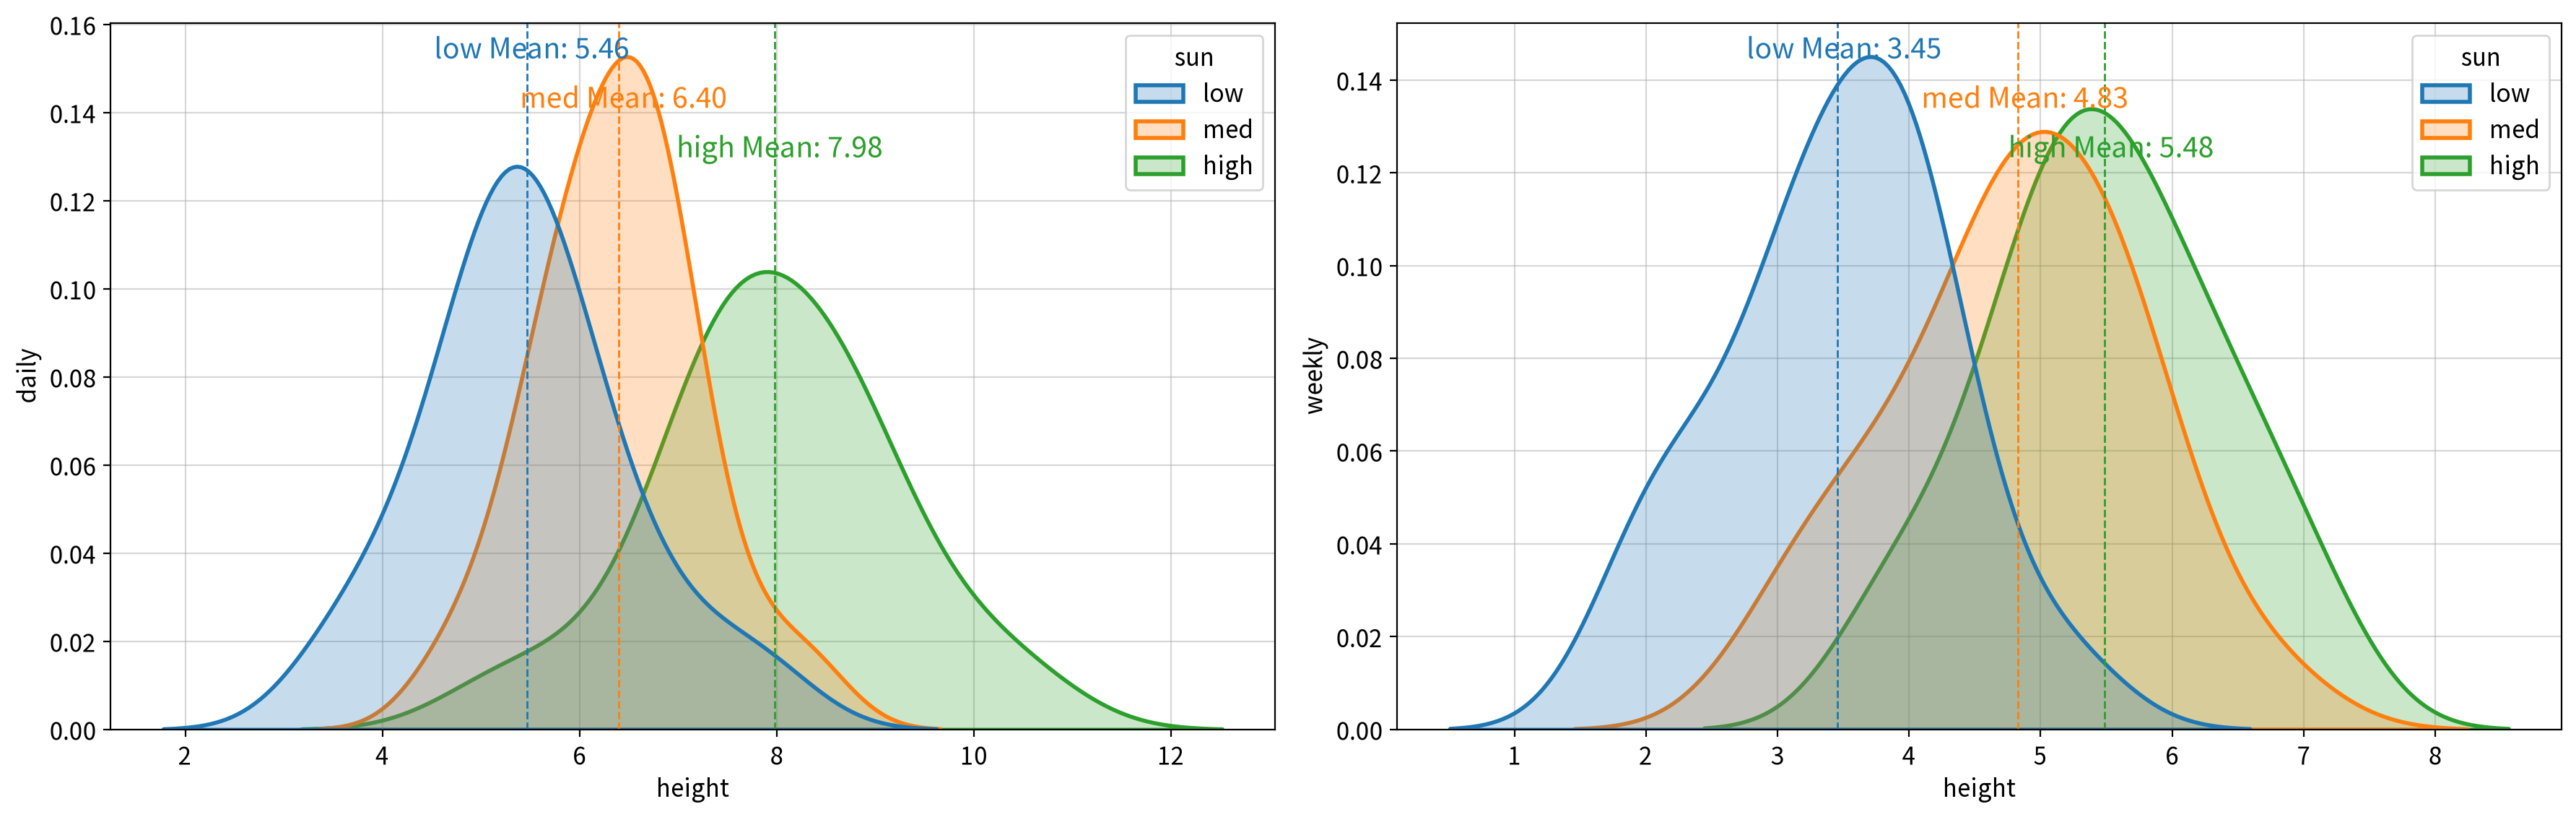

In [5]:
fig, ax = my_plot.init(cols=len(group_values), width=900, height=600)

for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]

    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, 
                    meanline=True, ax=ax[i])
    ax[i].set_ylabel(v)

my_plot.show()

### 3. 햇빛 노출량에 따른 관수빈도별 식물 높이 비교 

In [6]:
# 필요한 변수 정의 
field = 'height'    # 연속형 컬럼명 
group_field = 'sun'   # 명목형 컬럼명 1 (~~에 따른) 
hue_field = 'water'       # 명목형 컬럼명 2 (~~별)

# 그룹별 값의 종류 확인 
group_values = origin[group_field].unique()
print(f'그룹별 값의 종류: {group_values}')

# 시각화 할 필드만 원본 데이터에서 추출 
data = origin[[field, group_field, hue_field]]
data.head()

그룹별 값의 종류: <ArrowStringArray>
['low', 'med', 'high']
Length: 3, dtype: str


,height,sun,water
0,4.900,low,daily
1,7.900,low,daily
2,3.900,low,daily
3,5.100,low,daily
4,5.200,low,daily


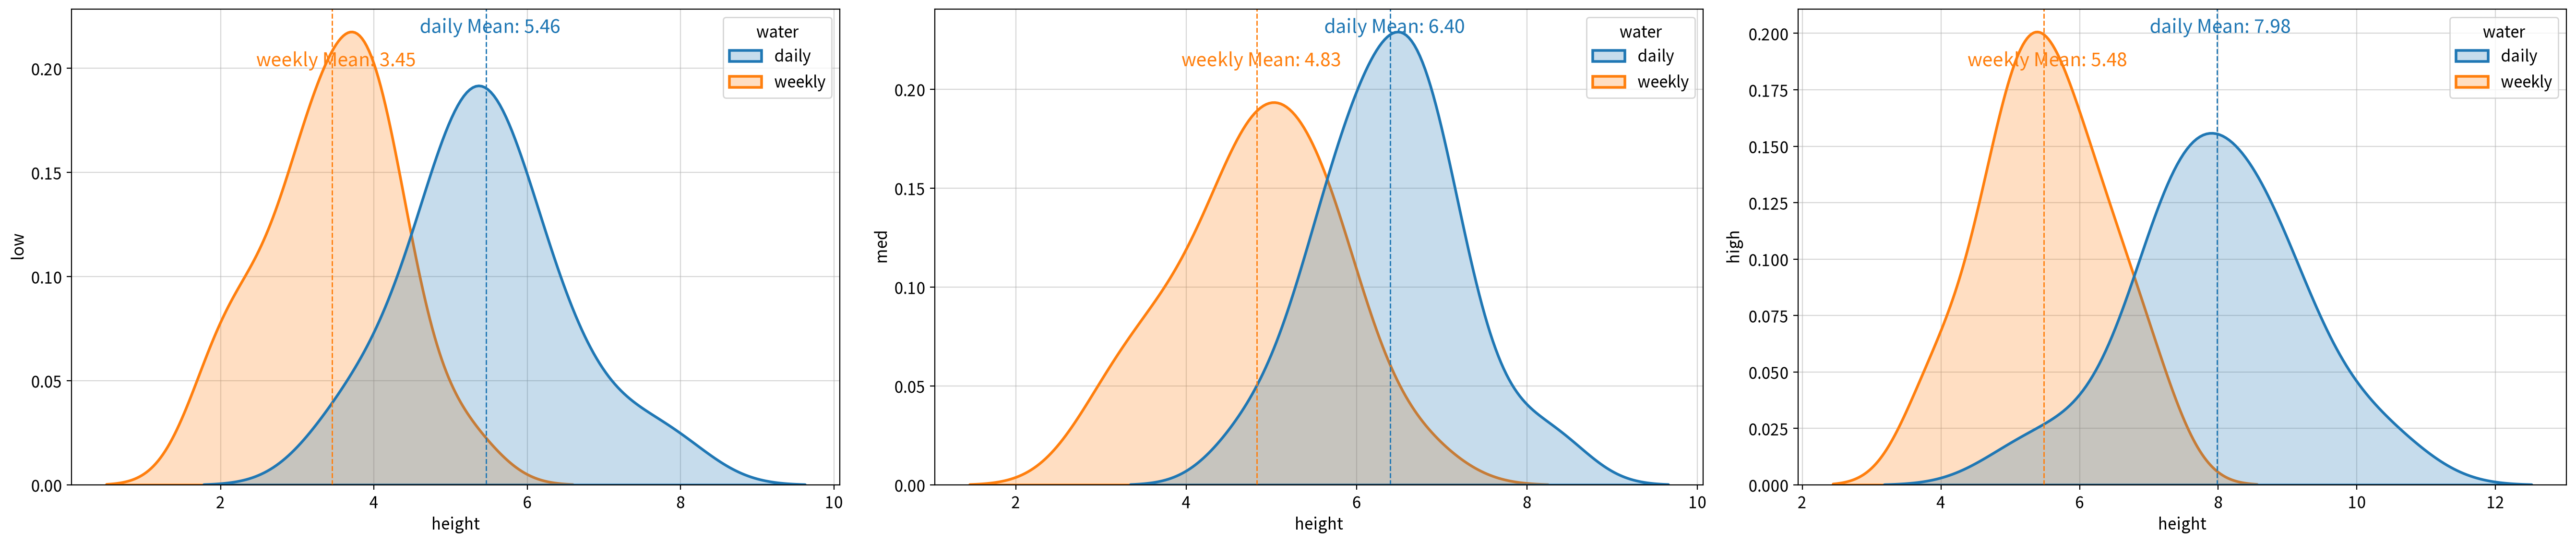

In [7]:
fig, ax = my_plot.init(cols=len(group_values), width=900, height=600)

for i, v in enumerate(group_values):
    temp = data[data[group_field] == v]

    my_plot.kdeplot(data=temp, x=field, hue=hue_field, fill=True, 
                    meanline=True, ax=ax[i])
    ax[i].set_ylabel(v)

my_plot.show()

## #03. 분산분석의 가정 확인 

### 1. 모든 명목형의 조합에 따른 종속변수 재배치 

In [8]:
data = origin.copy()
xname = ['water', 'sun']    # 명목형 변수의 이름 
yname = 'height'            # 연속형 변수의 이름 

# 두 명목형 변수의 모든 조합별로 연속형 변수 값을 별도의 컬럼으로 분리한다. 
groups = {}
for i in data[xname[0]].unique():
    for j in data[xname[1]].unique():
        # 명목형 변수의 조합 조건에 맞는 데이터를 추출한다. 
        filtered_data = data[(data[xname[0]]==i) & (data[xname[1]]==j)][yname]
        groups["{0}, {1}".format(i, j)] = filtered_data.reset_index(drop=True)

# 조합별 표본 크기가 다를 수 있으므로 DataFrame 으로 결합하면 짧은 쪽은 NaN으로 채워진다. 
# test_assumptions는 내부적으로 결측치를 제거한 뒤 검정하므로 문제되지 않는다. 
group_df = DataFrame(groups)
group_df.head()

,"daily, low","daily, med","daily, high","weekly, low","weekly, med","weekly, high"
0,4.900,5.600,8.600,3.900,4.800,5.200
1,7.900,6.500,8.800,3.300,3.600,4.700
2,3.900,6.500,9.200,4.300,5.700,6.900
3,5.100,6.000,7.100,3.300,4.100,5.100
4,5.200,7.100,8.600,4.500,4.600,7.100


### 2. 정규성에 따른 등분산성 검정 

In [9]:
# 정규성(normaltest)과 등분산성(Bartlett/ Levene)가정을 일괄 검정한다. 
rdf = my_stats.test_assumptions(group_df) 
display(rdf)

# 등분산성 충족 여부 ( 이후 사후검정 방법 선택에 사용) 
equal_var = bool(rdf.loc[rdf['test'] =='equal_var', 'result'].iloc[0])
equal_var

,test,statistic,p-value,result
field,,,,
"daily, low",normaltest,1.462,0.482,True
"daily, med",normaltest,0.867,0.648,True
"daily, high",normaltest,0.802,0.670,True
"weekly, low",normaltest,0.074,0.964,True
"weekly, med",normaltest,0.161,0.923,True
"weekly, high",normaltest,0.053,0.974,True
Bartlett,equal_var,4.488,0.481,True


True

## #03 이원분산분석 수행 

### 1. 가정 충족여부에 따른 이원분산분석 

In [10]:
# 분석 변수 정의 
data = origin.copy()
xname = ['water', 'sun']    # 명목형 (독립) 변수 
yname = 'height'            # 연속형 (종속) 변수 

# 등분산성 가정 (equal_var) 충족 여부에 따라 분석 방법 분기 
if equal_var: 
    # [등분산 충족] 일반 이원분산분석 
    aov = anova(data=data, dv=yname, between=xname).round(4)
    aov.insert(0, 'test', 'two-way ANOVA')
    # 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재) 
    aov['significant'] = aov['p_unc'] < 0.05

    # 효과크기 (np2, partial eta-squared) 해석 (>=0.14zma / >=0.06중간 / >=0.01 작음)
    conditions = [ aov['np2'] >= 0.14, 
                  aov['np2'] >= 0.06, 
                  aov['np2'] >= 0.01 ]
    aov['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], 
                                   default='Negligible')

else: 
    # [등분산 미충족] 등분산을 가정하지 않는 선형모형(HC3) 기반 Type-II ANOVA
    model = ols(f'{yname} ~ c({xname[0]}) * C({xname[1]})', data=data)
    fit = model.fit(cov_type='HC3')
    aov = sm.stats.anova_lm(fit, typ=2, robust='hc3').round(4)
    aov.insert(0, 'test', 'OLS (HC3) Type-II ANOVA')
    # 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재) 
    # -> p-value 컬럼명이 'PR(>F)'로 되어있으므로 해당 컬럼명을 사용 
    aov['significant'] = aov['PR(>F)'] < 0.05
aov

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,True,Large
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,True,Large
2,two-way ANOVA,water * sun,4.327,2,2.164,2.300,0.105,0.039,False,Small
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,False,Negligible


## #04. 이원분산분석 시각화 

### 1. 햇빛 노출량에 따른 관수 빈도별 평균 식물 높이 

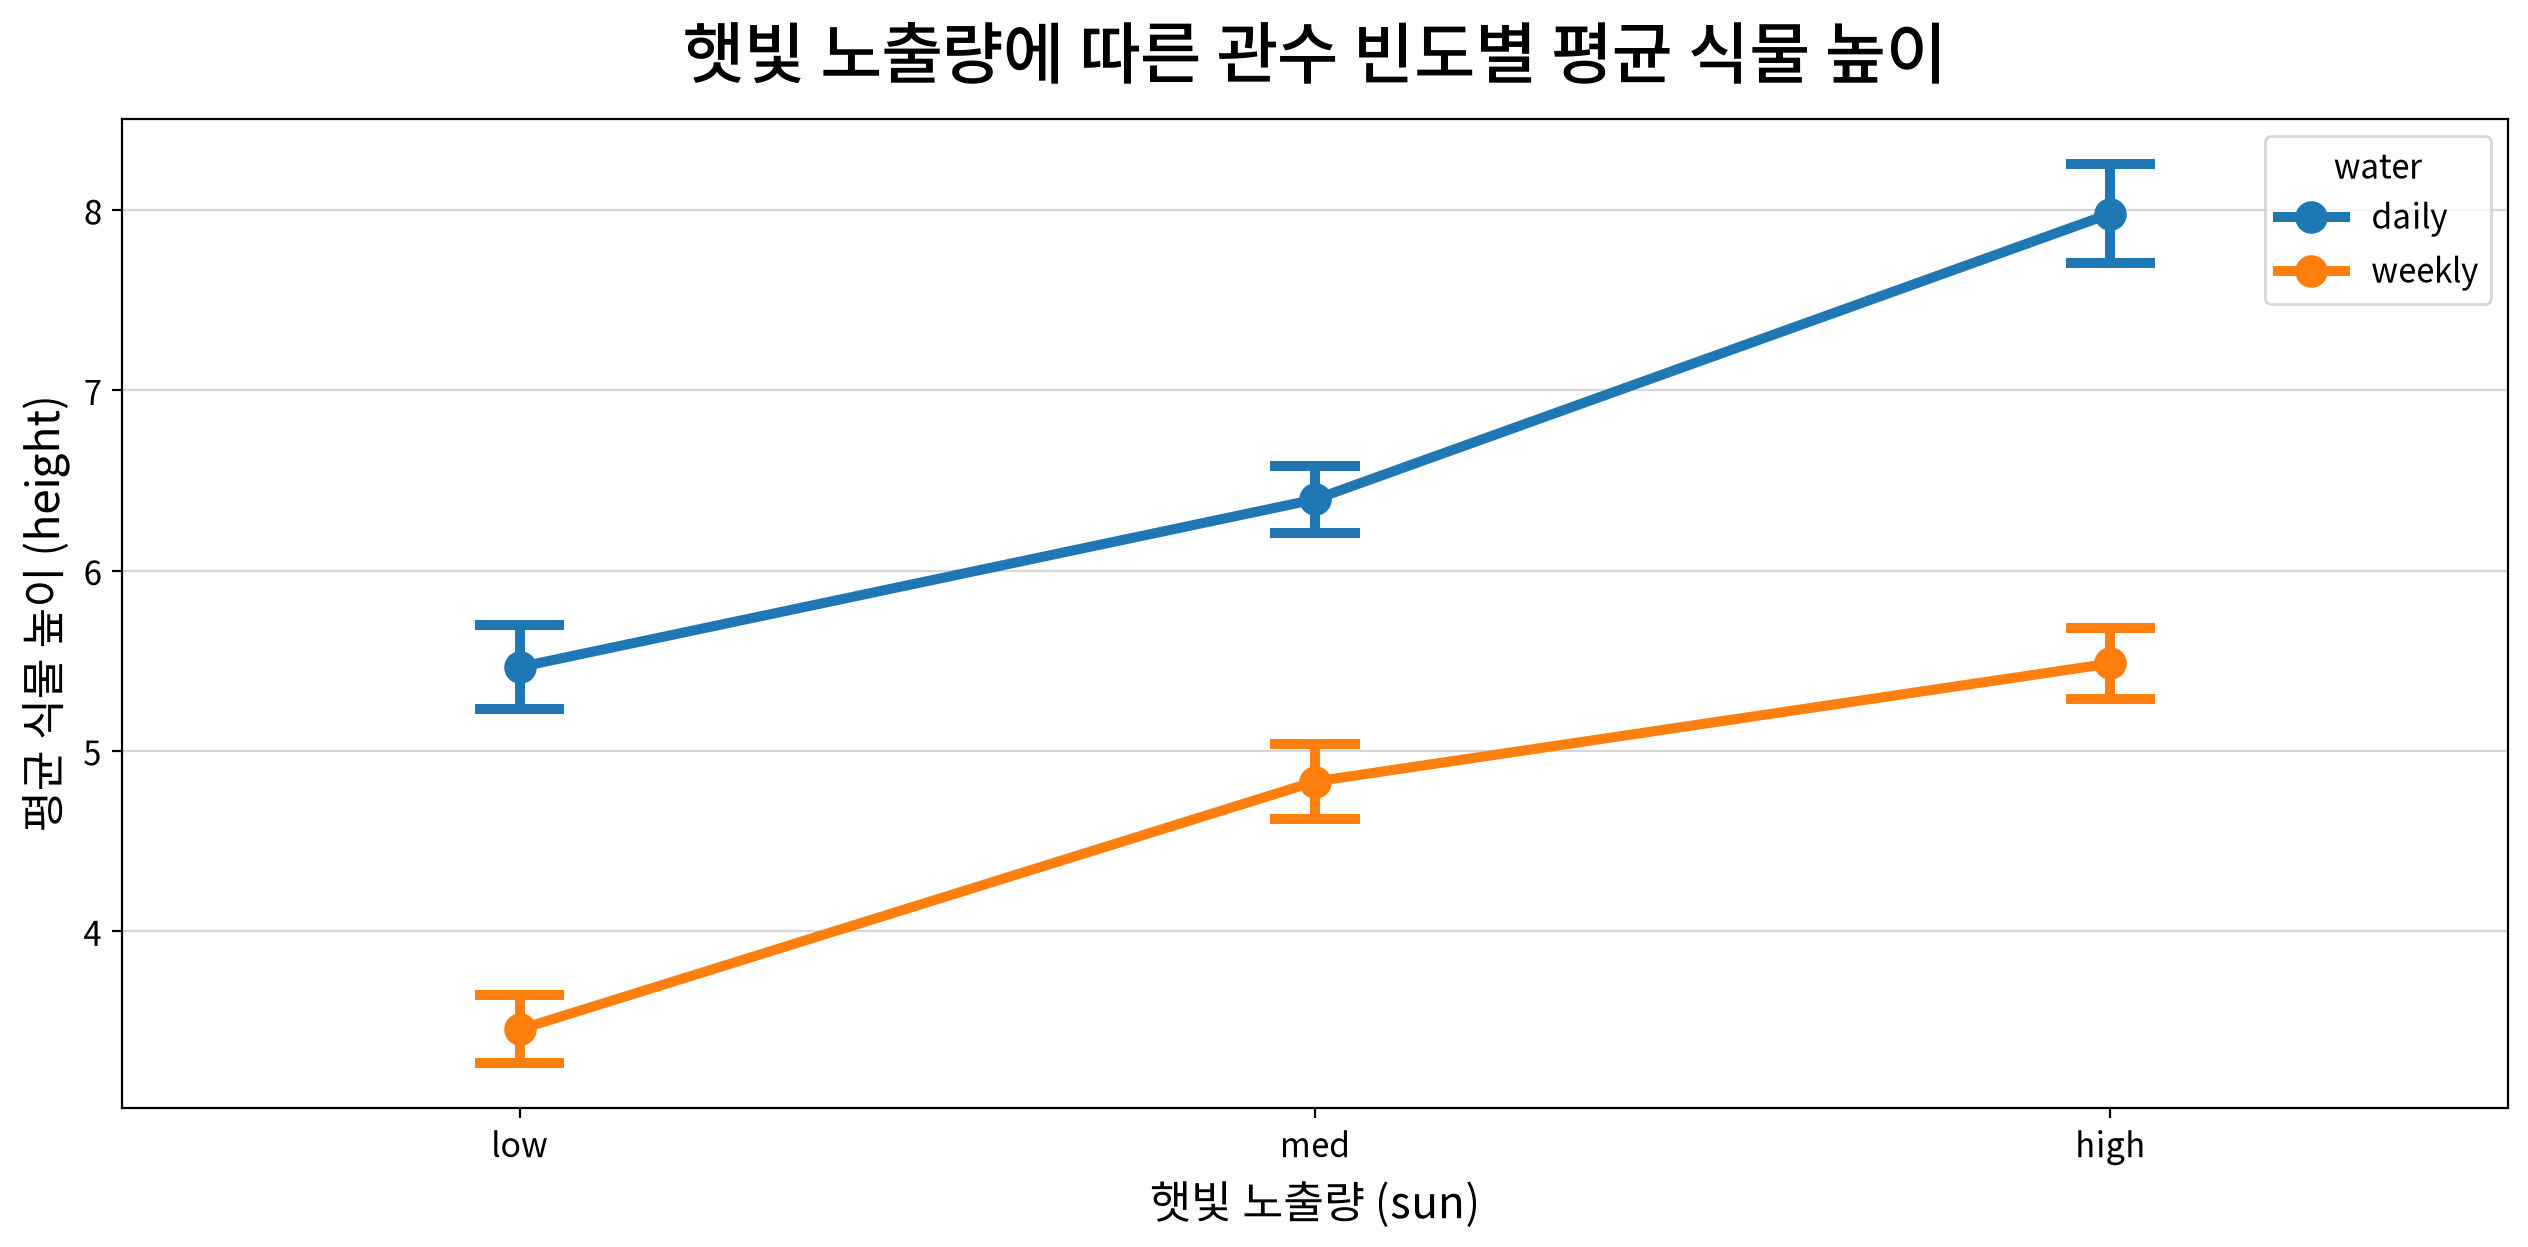

In [11]:
# 햇빛 노출량을 적은 -> 많은 순으로 정렬 
sun_order = ['low', 'med', 'high']

# 상호작용 플롯 - 햇빛 노출량(x축)에 따른 평균 식물 높이를 관수(선) 별로 비교한다. 
fig, ax = my_plot.init(title='햇빛 노출량에 따른 관수 빈도별 평균 식물 높이', 
                       xlabel='햇빛 노출량 (sun)', ylabel='평균 식물 높이 (height)')

# errorbar = 'se' --> 표준오차(standard error)를 계산하여 오차막대(error bar)표시 
# capsizes = 0.1 --> 오차막대 끝에 수평선 표시 (순전히 가독성용이라 통계적 의미 없음) 
sb.pointplot(data=origin, x='sun', y='height', hue='water', 
             errorbar='se', capsize=0.1, order=sun_order, ax=ax)

my_plot.show()

### 2. 관수 빈도에 따른 햇빛 노출량별 평균 식물 높이 

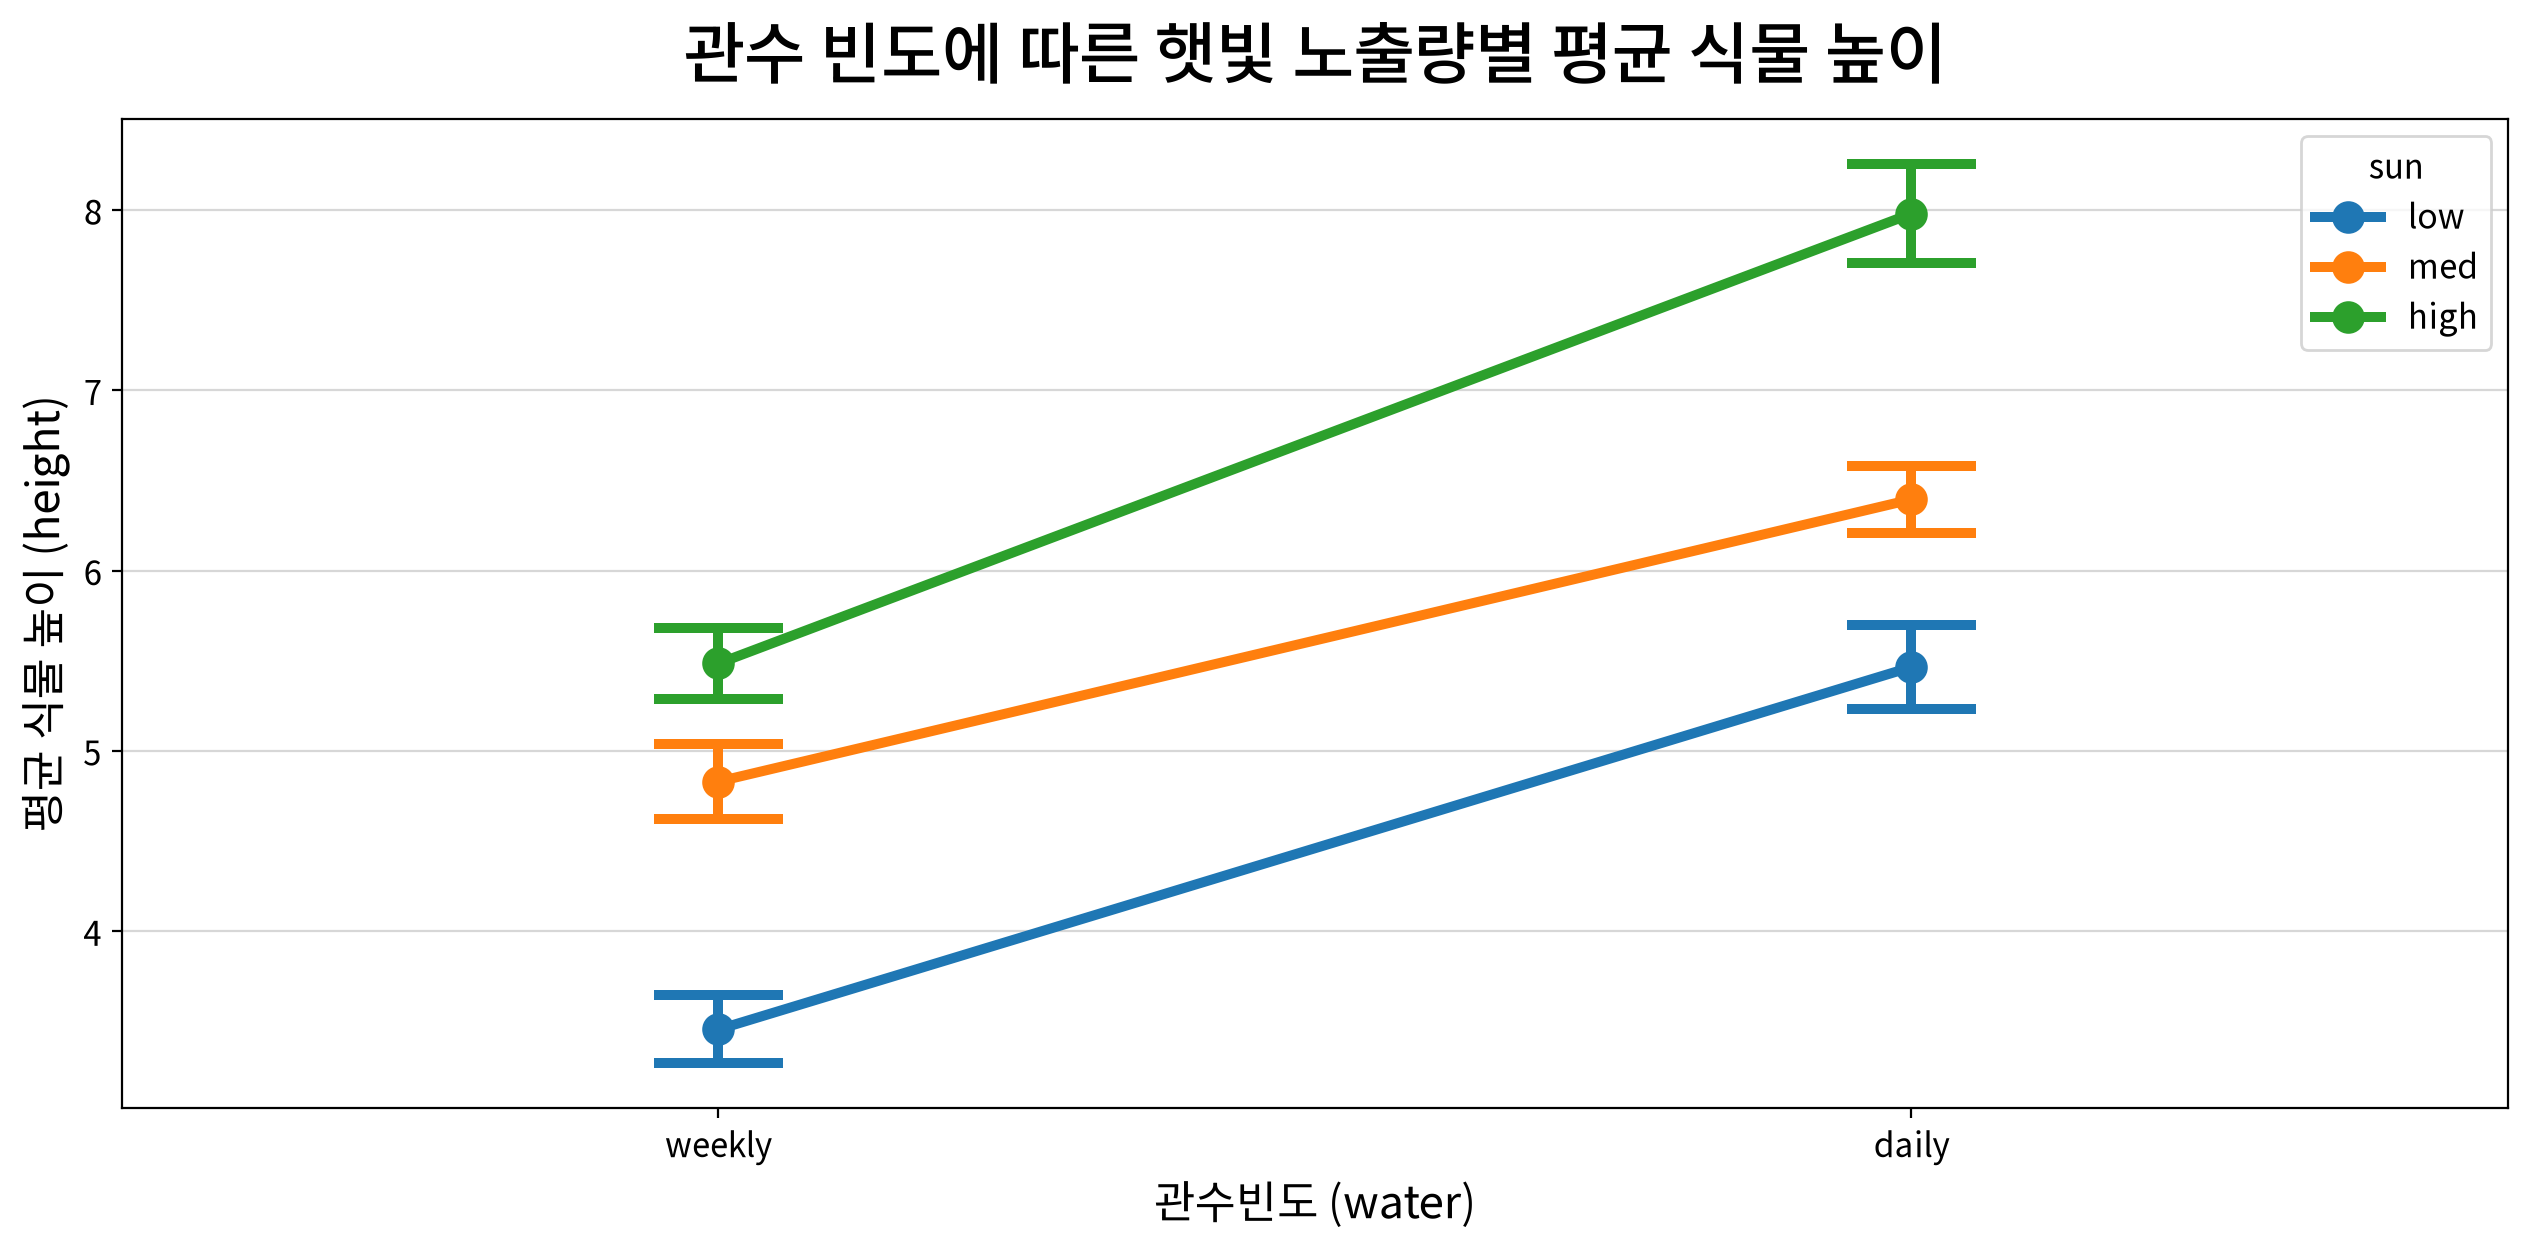

In [12]:
# 햇빛 노출량을 적은 -> 많은 순으로 정렬 
water_order = ['weekly', 'daily']

# 상호작용 플롯 - 햇빛 노출량(x축)에 따른 평균 식물 높이를 관수(선) 별로 비교한다. 
fig, ax = my_plot.init(title='관수 빈도에 따른 햇빛 노출량별 평균 식물 높이', 
                       xlabel='관수빈도 (water)', ylabel='평균 식물 높이 (height)')

# errorbar = 'se' --> 표준오차(standard error)를 계산하여 오차막대(error bar)표시 
# capsizes = 0.1 --> 오차막대 끝에 수평선 표시 (순전히 가독성용이라 통계적 의미 없음) 
sb.pointplot(data=origin, x='water', y='height', hue='sun', 
             errorbar='se', capsize=0.1, order=water_order, ax=ax)

my_plot.show()

## #05. 모듈화 기능 확인 

### 이원분산분석의 시각화 및 분석 결과 표 

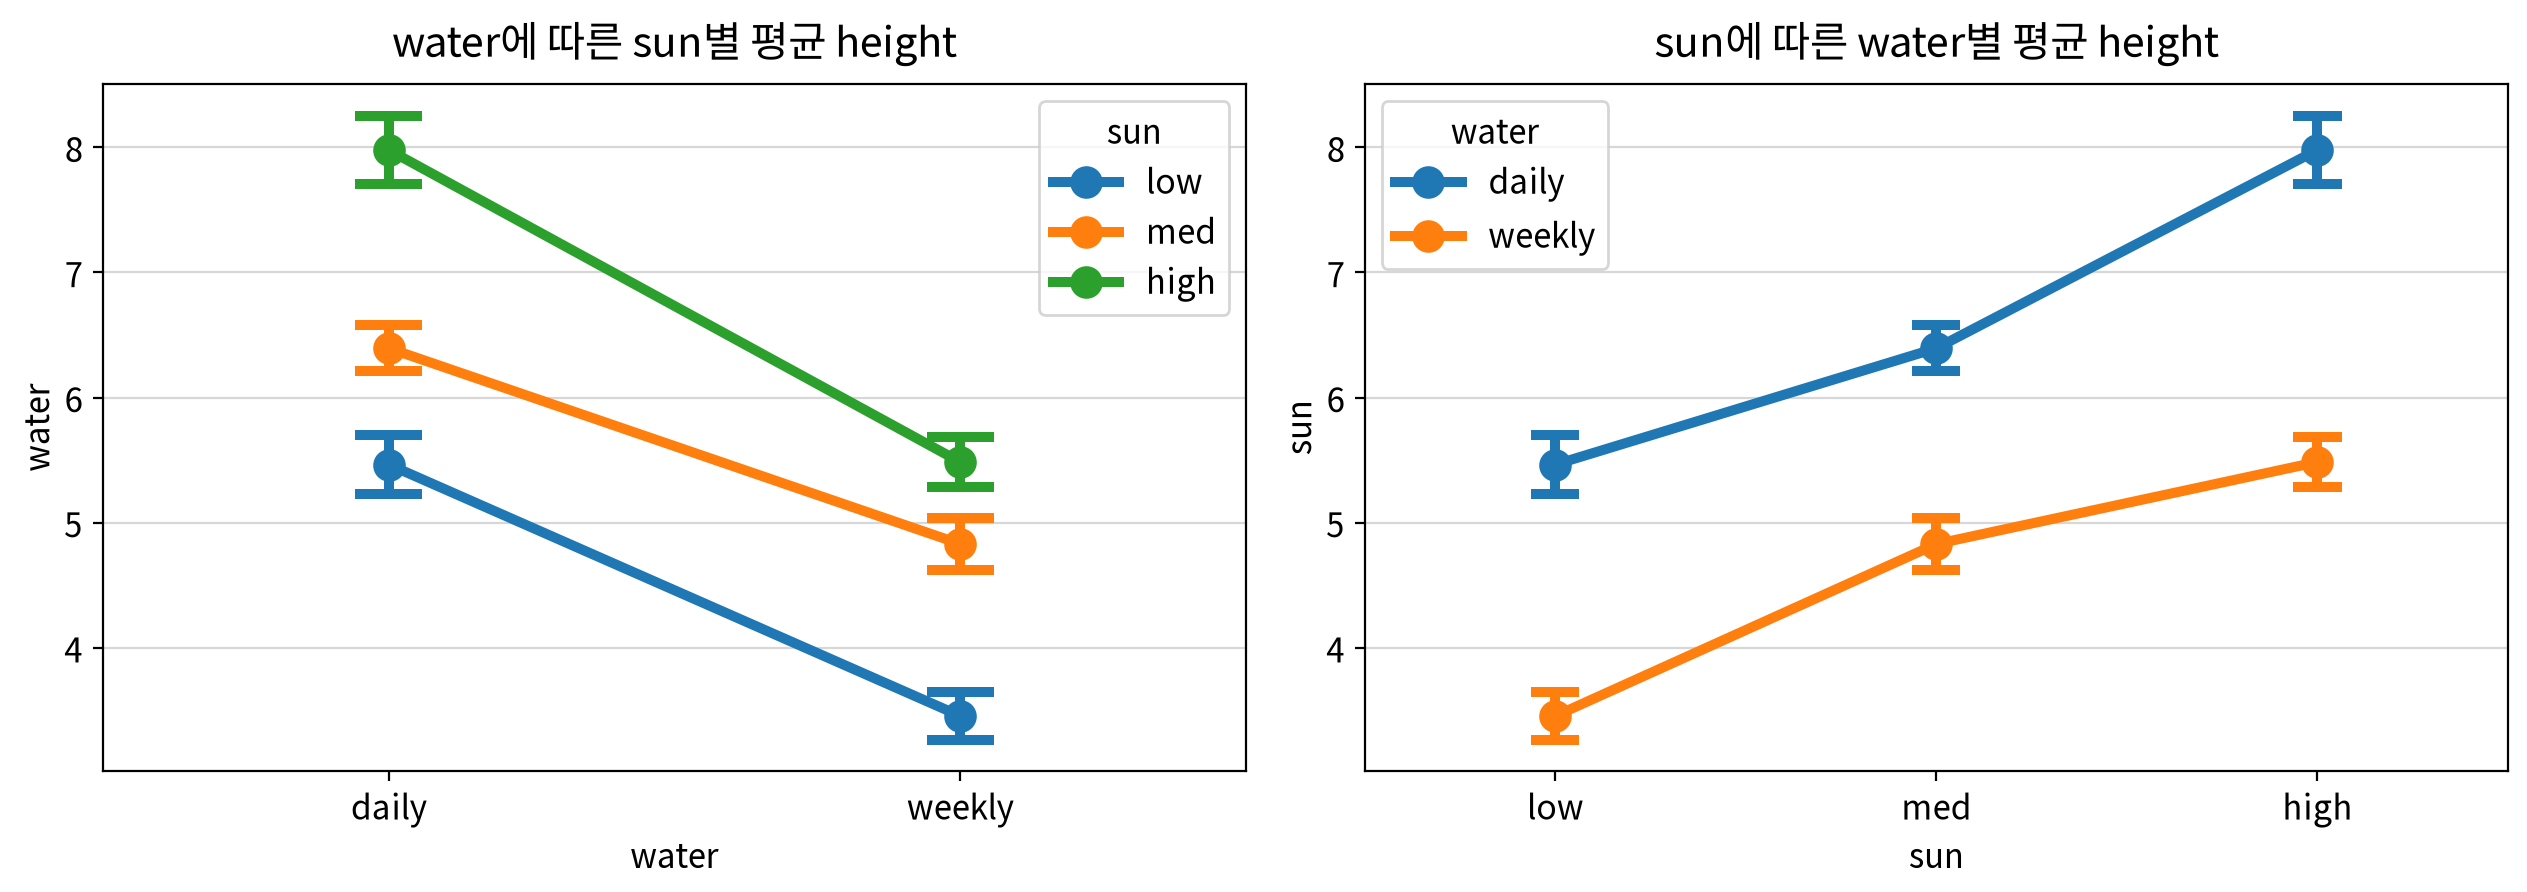

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,water,122.816,1,122.816,130.529,0.000,0.534,True,Large
1,two-way ANOVA,sun,103.292,2,51.646,54.889,0.000,0.491,True,Large
2,two-way ANOVA,water * sun,4.327,2,2.164,2.299,0.105,0.039,False,Small
3,two-way ANOVA,Residual,107.264,114,0.941,NaN,NaN,NaN,False,-


In [13]:
my_stats.anova_twoway(origin, y='height', between=['water', 'sun'])

## #01. 연습문제 

In [14]:
from pandas import melt

In [15]:
origin = load_data('edu') 
origin.head()

📚 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


In [16]:
df = melt(origin, 
          id_vars='교육방법', 
          value_vars=['국어', '영어'], 
          var_name='과목', 
          value_name='점수')
df.head()

,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


In [58]:
print(f"관측치 개수 : {len(df)}")

관측치 개수 : 44


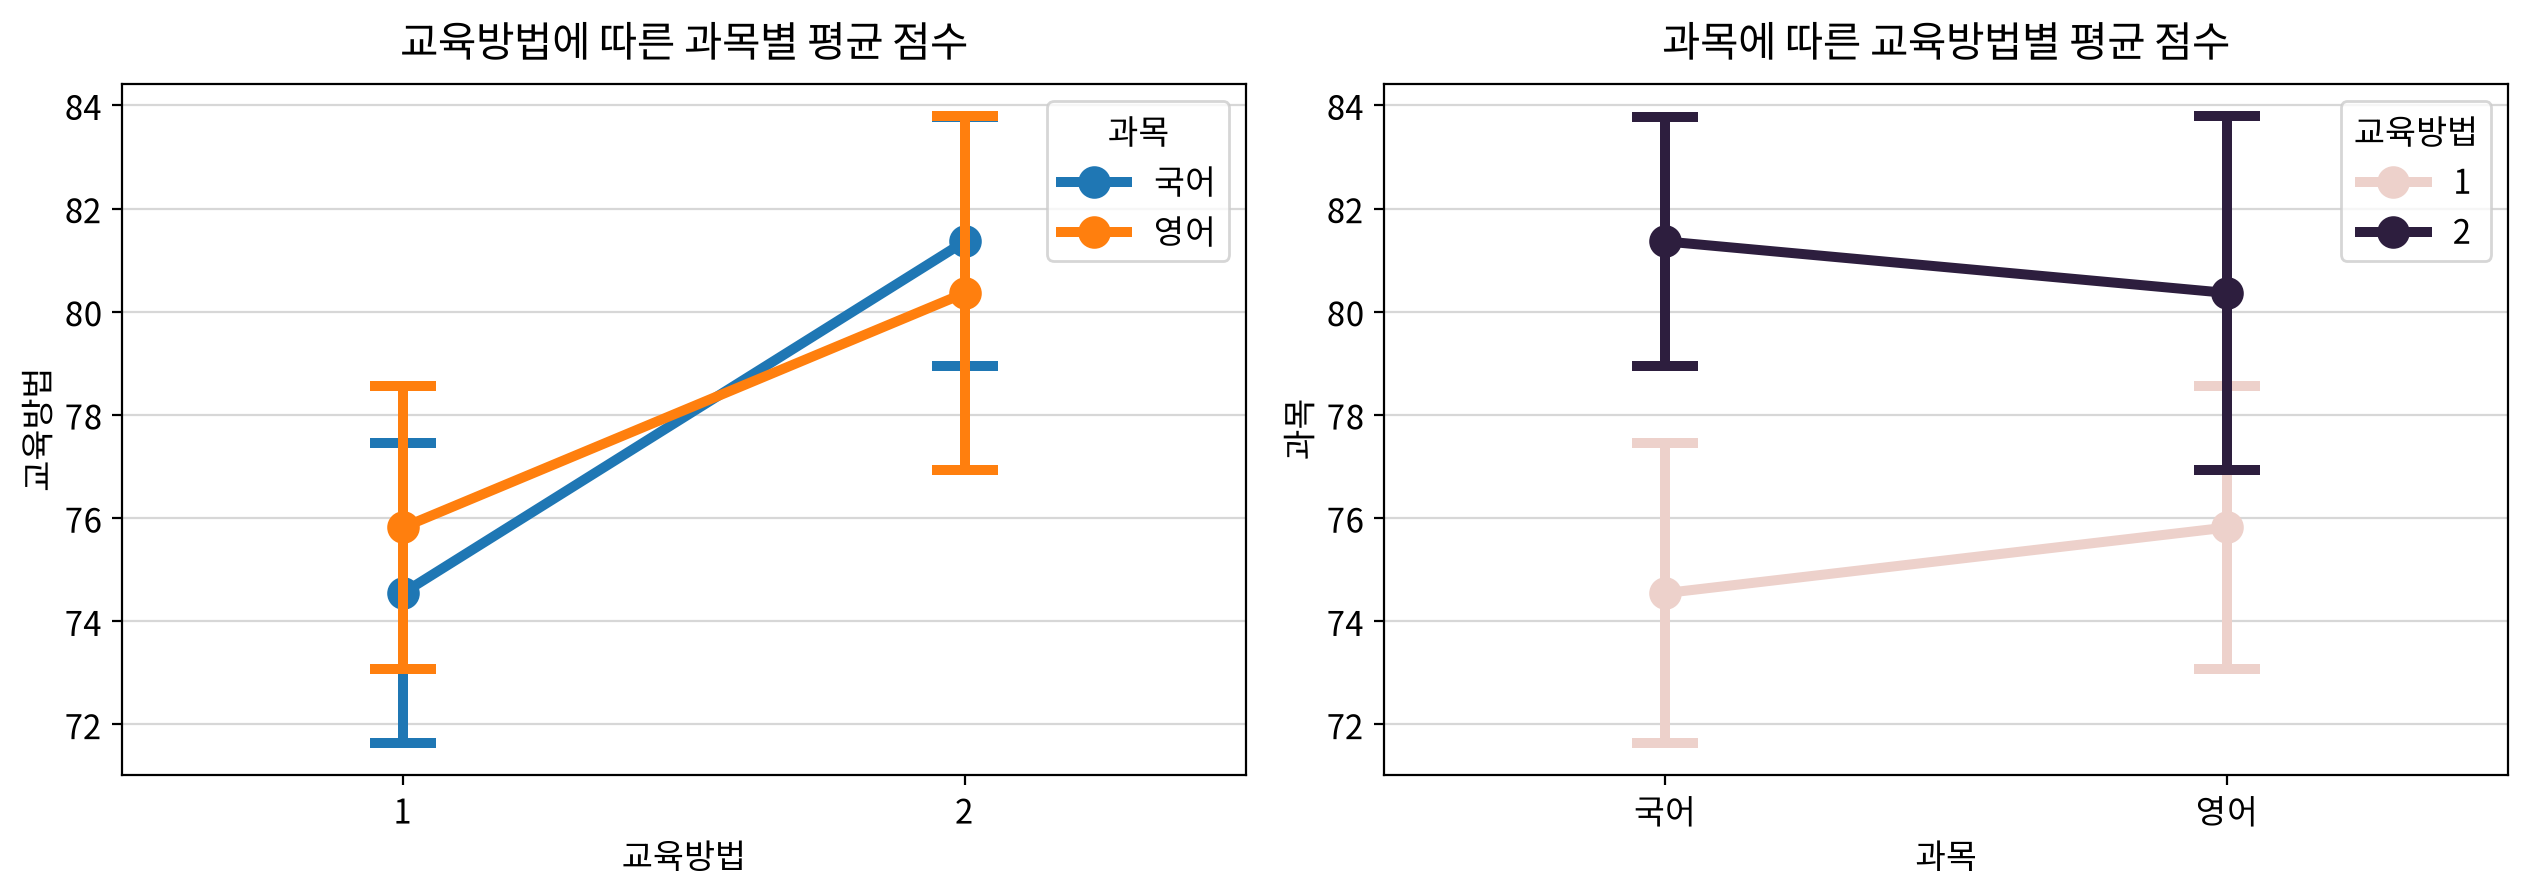

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,교육방법,355.114,1,355.114,3.846,0.057,0.088,False,Medium
1,two-way ANOVA,과목,0.205,1,0.205,0.002,0.963,0.000,False,Negligible
2,two-way ANOVA,교육방법 * 과목,14.205,1,14.205,0.154,0.697,0.004,False,Negligible
3,two-way ANOVA,Residual,3693.455,40,92.336,NaN,NaN,NaN,False,-


In [17]:
my_stats.anova_twoway(df, y='점수', between=['교육방법', '과목'])

## #02. 연습문제 

In [18]:
# 세가지 독극물 각각에, 네가지 해독제를 투여함
# 3 X 4  = 12가지 경우의 수 

# posion에 따른 treat의 time
# treat에 따른 poison의 time 

# 그래서 종류별로 묶어서 봐야 한다는건가. 

In [19]:
origin = load_data('poisons')
origin

📚 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)


,time,poison,treat
0,3.800,P1,T1
1,2.700,P1,T1
2,1.700,P1,T1
3,2.200,P1,T1
4,0.700,P1,T1
...,...,...,...
355,4.700,P3,T4
356,4.900,P3,T4
357,4.900,P3,T4
358,4.500,P3,T4


In [20]:
print(f"독극물 종류: {sorted(origin['poison'].unique())}")
print(f"해독제 종류: {sorted(origin['treat'].unique())}")
print(f"처리 조합(셀) 수: {origin.groupby(['poison', 'treat']).ngroups}")
print(f"조합당 개체 수: {origin.groupby(['poison', 'treat']).size().unique()}")

독극물 종류: ['P1', 'P2', 'P3']
해독제 종류: ['T1', 'T2', 'T3', 'T4']
처리 조합(셀) 수: 12
조합당 개체 수: [30]


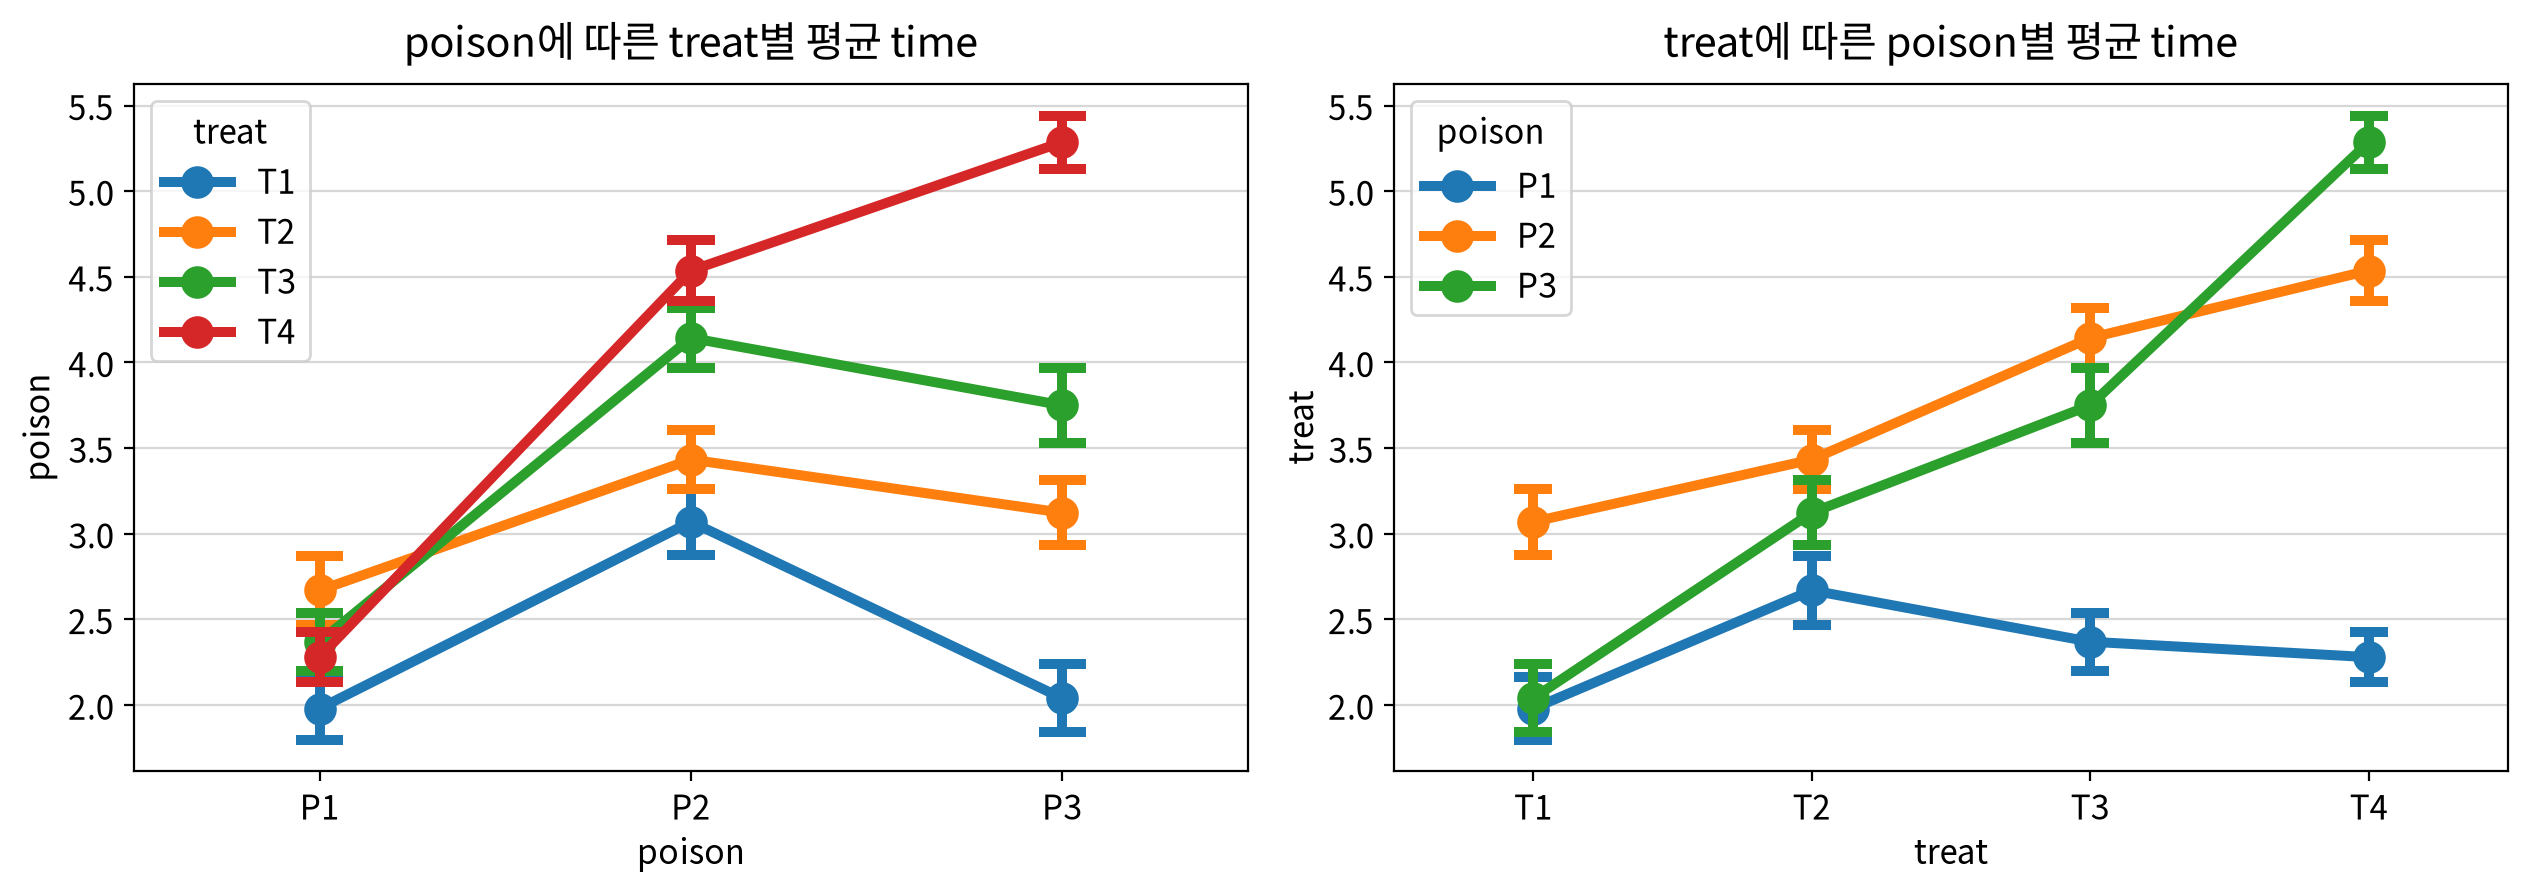

,test,Source,SS,DF,MS,F,p_unc,np2,significant,effect_size
0,two-way ANOVA,poison,148.976,2,74.488,74.722,0.000,0.300,True,Large
1,two-way ANOVA,treat,131.261,3,43.754,43.891,0.000,0.275,True,Large
2,two-way ANOVA,poison * treat,81.382,6,13.564,13.606,0.000,0.190,True,Large
3,two-way ANOVA,Residual,346.910,348,0.997,NaN,NaN,NaN,False,-


In [21]:
my_stats.anova_twoway(origin, y='time', between=['poison', 'treat'])

# 8-2 이원분산분석의 사후검정 

## #01. 준비작업 

### 1. 라이브러리 참조 

In [22]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
import numpy as np

# 사후검정을 위한 라이브러리 
from pingouin import pairwise_tukey, pairwise_gameshowell

### 2. 데이터 가져오기 

In [23]:
origin = load_data('sunlight_watering_growth')
origin.head()

📚 식물의 씨앗을 심고 햇빛 노출과 물 주기를 다른 조건으로 하여 두 달 동안 자라게 한 후 각 식물의 높이를 인치 단위로 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,water,sun,height
0,daily,low,4.900
1,daily,low,7.900
2,daily,low,3.900
3,daily,low,5.100
4,daily,low,5.200


## #02. 분산분석의 가정 확인 

### 1. 모든 명목형의 조합에 따른 종속변수 재배치 

In [24]:
data = origin.copy()
xname = ['water', 'sun'] # 명목형 변수의 이름 
yname = 'height'         # 연속형 변수의 이름 

# 두 명목형 변수의 모든 조합별로 연속형 변수 값을 별도의 컬럼으로 분리한다. 
groups = {} 
for i in data[xname[0]].unique():
    for j in data[xname[1]].unique():
        # 명목형 변수의 조합 조건에 맞는 데이터를 추출한다. 
        filtered_data = data[(data[xname[0]] == i ) & (data[xname[1]] == j)][yname]
        groups["{0}, {1}".format(i, j)] = filtered_data.reset_index(drop=True)

# 조합별 표본 크기가 다를 수 있으므로 DataFrame으로 결합하면 짧은 쪽은 NaN으로 채워진다. 
# test_assumptions는 내부적으로 결측치를 제거한 뒤 검정하므로 문제되지 않는다. 
group_df = DataFrame(groups) 
group_df.head()

,"daily, low","daily, med","daily, high","weekly, low","weekly, med","weekly, high"
0,4.900,5.600,8.600,3.900,4.800,5.200
1,7.900,6.500,8.800,3.300,3.600,4.700
2,3.900,6.500,9.200,4.300,5.700,6.900
3,5.100,6.000,7.100,3.300,4.100,5.100
4,5.200,7.100,8.600,4.500,4.600,7.100


### 2. 정규성에 따른 등분산성 검정 

In [25]:
# 정규성 (normaltest)과 등분산성(Bartlett/ Levene) 가정을 일괄 검정한다. 
rdf = my_stats.test_assumptions(group_df) 
display(rdf)

# 등분산성 충족 여부 (이후 사후검정 방법 선택에 사용) 
equal_var = bool(rdf.loc[rdf['test'] == 'equal_var', 'result'].iloc[0])
equal_var

,test,statistic,p-value,result
field,,,,
"daily, low",normaltest,1.462,0.482,True
"daily, med",normaltest,0.867,0.648,True
"daily, high",normaltest,0.802,0.670,True
"weekly, low",normaltest,0.074,0.964,True
"weekly, med",normaltest,0.161,0.923,True
"weekly, high",normaltest,0.053,0.974,True
Bartlett,equal_var,4.488,0.481,True


True

## #03. 사후검정 (Post-hoc)

### 1. water와 sun의 조합이름 컬럼 생성 

In [26]:
ph = origin.copy()
ph['group'] = ph['water'] + ', ' + ph['sun'] 
ph.head()

,water,sun,height,group
0,daily,low,4.900,"daily, low"
1,daily,low,7.900,"daily, low"
2,daily,low,3.900,"daily, low"
3,daily,low,5.100,"daily, low"
4,daily,low,5.200,"daily, low"


### 2. 등분산성 가정에 따른 사후검정 방법 분기 

In [27]:
if equal_var: 
    posthoc_name = 'Tukey HSD'
    posthoc = pairwise_tukey(data=ph, dv=yname, between='group') 
    # 유의수준 컬럼명 변경 
    posthoc.rename(columns={'p_tukey': 'pval'}, inplace=True) 
else: 
    posthoc_name = 'Games-Howell'
    posthoc = pairwise_gameshowell(data=ph, dv=yname, between='group') 

# 어떤 사후검정을 사용했는지 식별용 컬럼 추가 
posthoc.insert(0, 'test', posthoc_name)

posthoc

,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.216
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043


### 3. 출력 결과 가공하기 

In [28]:
# 사후검정 결과에 유의성 판정 컬럼 추가 (p < 0.05 이면 효과 존재) 
posthoc['significant'] = posthoc['pval'] < 0.05

# 효과크기 해석 (>= 0.08큼 / >=0.5 중간 / >=0.2 작음) 
abs_hedges = posthoc['hedges'].abs()
conditions = [abs_hedges >= 0.8, abs_hedges >=0.5, abs_hedges >=0.2]
posthoc['effect_size'] = np.select(conditions, ['Large', 'Medium', 'Small'], default='Negligible')

# 그룹 이름순으로 정렬 
posthoc.sort_values(['A', 'B'], inplace=True)

# 사후검정 결과를 시각적으로 강조하기 위해 p-value 컬럼에 색상 그라데이션 적용 
style = posthoc.style.background_gradient(cmap='Reds', subset=['pval']) 

style 

,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980000,5.465000,2.515000,0.306743,8.199048,0.000000,2.165102,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980000,6.395000,1.585000,0.306743,5.167193,0.000015,1.488325,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980000,5.485000,2.495000,0.306743,8.133847,0.000000,2.288309,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980000,3.455000,4.525000,0.306743,14.751766,0.000000,4.215536,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980000,4.830000,3.150000,0.306743,10.269185,0.000000,2.831045,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465000,6.395000,-0.930000,0.306743,-3.031855,0.034790,-0.968866,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465000,5.485000,-0.020000,0.306743,-0.065201,1.000000,-0.020244,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465000,3.455000,2.010000,0.306743,6.552718,0.000000,2.073754,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465000,4.830000,0.635000,0.306743,2.070137,0.310347,0.627126,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395000,5.485000,0.910000,0.306743,2.966653,0.041647,1.043256,True,Large


### 4. 사후검정 결과 요약 

In [29]:
print(f"비교한 조합 쌍: {len(posthoc)}개")
print(f"유의한 쌍 : {int(posthoc['significant'].sum())}개")

big = posthoc.loc[posthoc['diff'].abs().idxmax()]
print(f"평균 차이가 가장 큰 쌍 : ({big['A']}) vs ({big['B']})" 
      f"-> 차이 {abs(big['diff']):.3f}, 효과크기 {big['effect_size']}, p-value {big['pval']:.3f}")

sm = posthoc.loc[posthoc['diff'].abs().idxmin()]
print(f"평균 차이가 가장 작은 쌍 : ({sm['A']}) vs ({sm['B']})"
      f"-> 차이 {abs(sm['diff']):.3f}, 효과크기 {sm['effect_size']}, p-value {sm['pval']:.3f} ")

비교한 조합 쌍: 15개
유의한 쌍 : 12개
평균 차이가 가장 큰 쌍 : (daily, high) vs (weekly, low)-> 차이 4.525, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍 : (daily, low) vs (weekly, high)-> 차이 0.020, 효과크기 Negligible, p-value 1.000 


### 5. 같은 관수빈도 안에서의 햇빛량 비교 

In [30]:
for p in ['daily', 'weekly']: 
    sub = (posthoc[posthoc['A'].str.startswith(p) & posthoc['B'].str.startswith(p)])
    
    # 유의한 쌍 (significant == True)만 추출
    sig = sub[sub['significant']]

    print(f"\n[{p}] {len(sub)}쌍 중 유의한 쌍 : {len(sig)}개")
    print(sig[['A', 'B', 'diff', 'pval', 'significant']].to_string(index=False))


[daily] 3쌍 중 유의한 쌍 : 3개
          A          B   diff  pval  significant
daily, high daily, low  2.515 0.000         True
daily, high daily, med  1.585 0.000         True
 daily, low daily, med -0.930 0.035         True

[weekly] 3쌍 중 유의한 쌍 : 2개
           A           B   diff  pval  significant
weekly, high weekly, low  2.030 0.000         True
 weekly, low weekly, med -1.375 0.000         True


## #04. 사후검정 시각화(박스플롯) 

### 1. 그래프 정렬 순서 생성 

In [31]:
order = (ph[['group', 'height']].groupby('group').mean()
         .sort_values('height', ascending=False).index.tolist())

order 

['daily, high',
 'daily, med',
 'weekly, high',
 'daily, low',
 'weekly, med',
 'weekly, low']

### 2. 상자그림 시각화 

C:\py_temp\15_LAB\helpers\my_plot.py:312: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data, x=x, y=y, hue=hue, orient=orient, order=order, palette=palette, ax=ax)


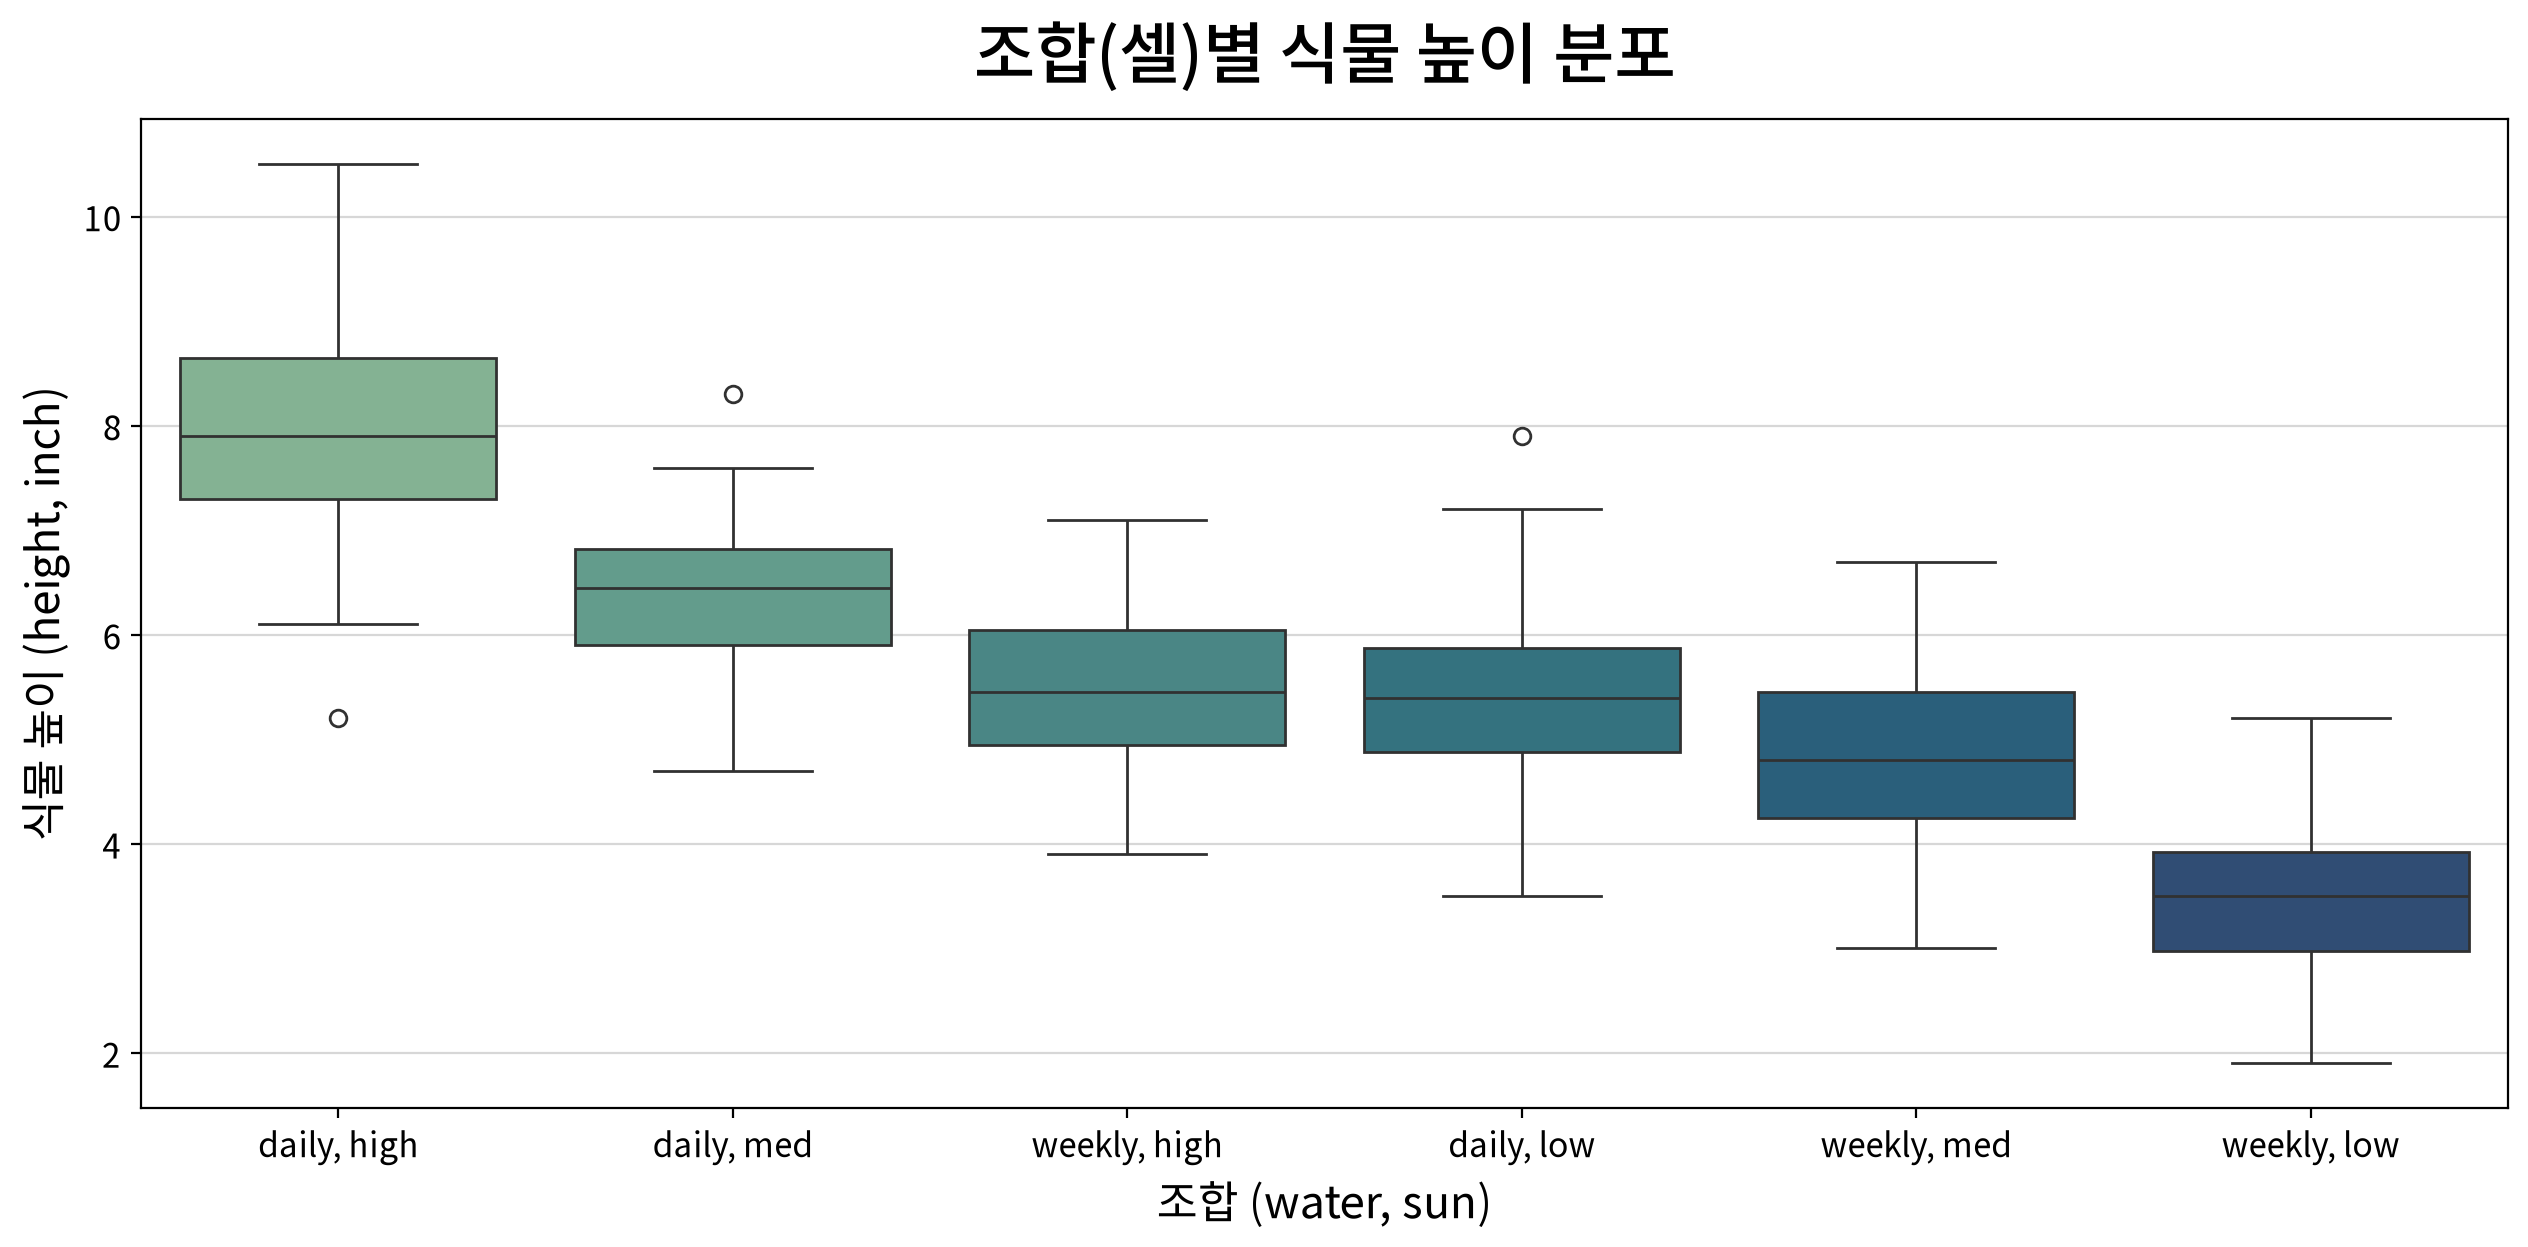

In [32]:
my_plot.boxplot(data = ph, x='group', y='height', order=order, palette='crest', 
                title = '조합(셀)별 식물 높이 분포', 
                xlabel='조합 (water, sun)', 
                ylabel='식물 높이 (height, inch)')

C:\py_temp\15_LAB\helpers\my_plot.py:312: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data, x=x, y=y, hue=hue, orient=orient, order=order, palette=palette, ax=ax)


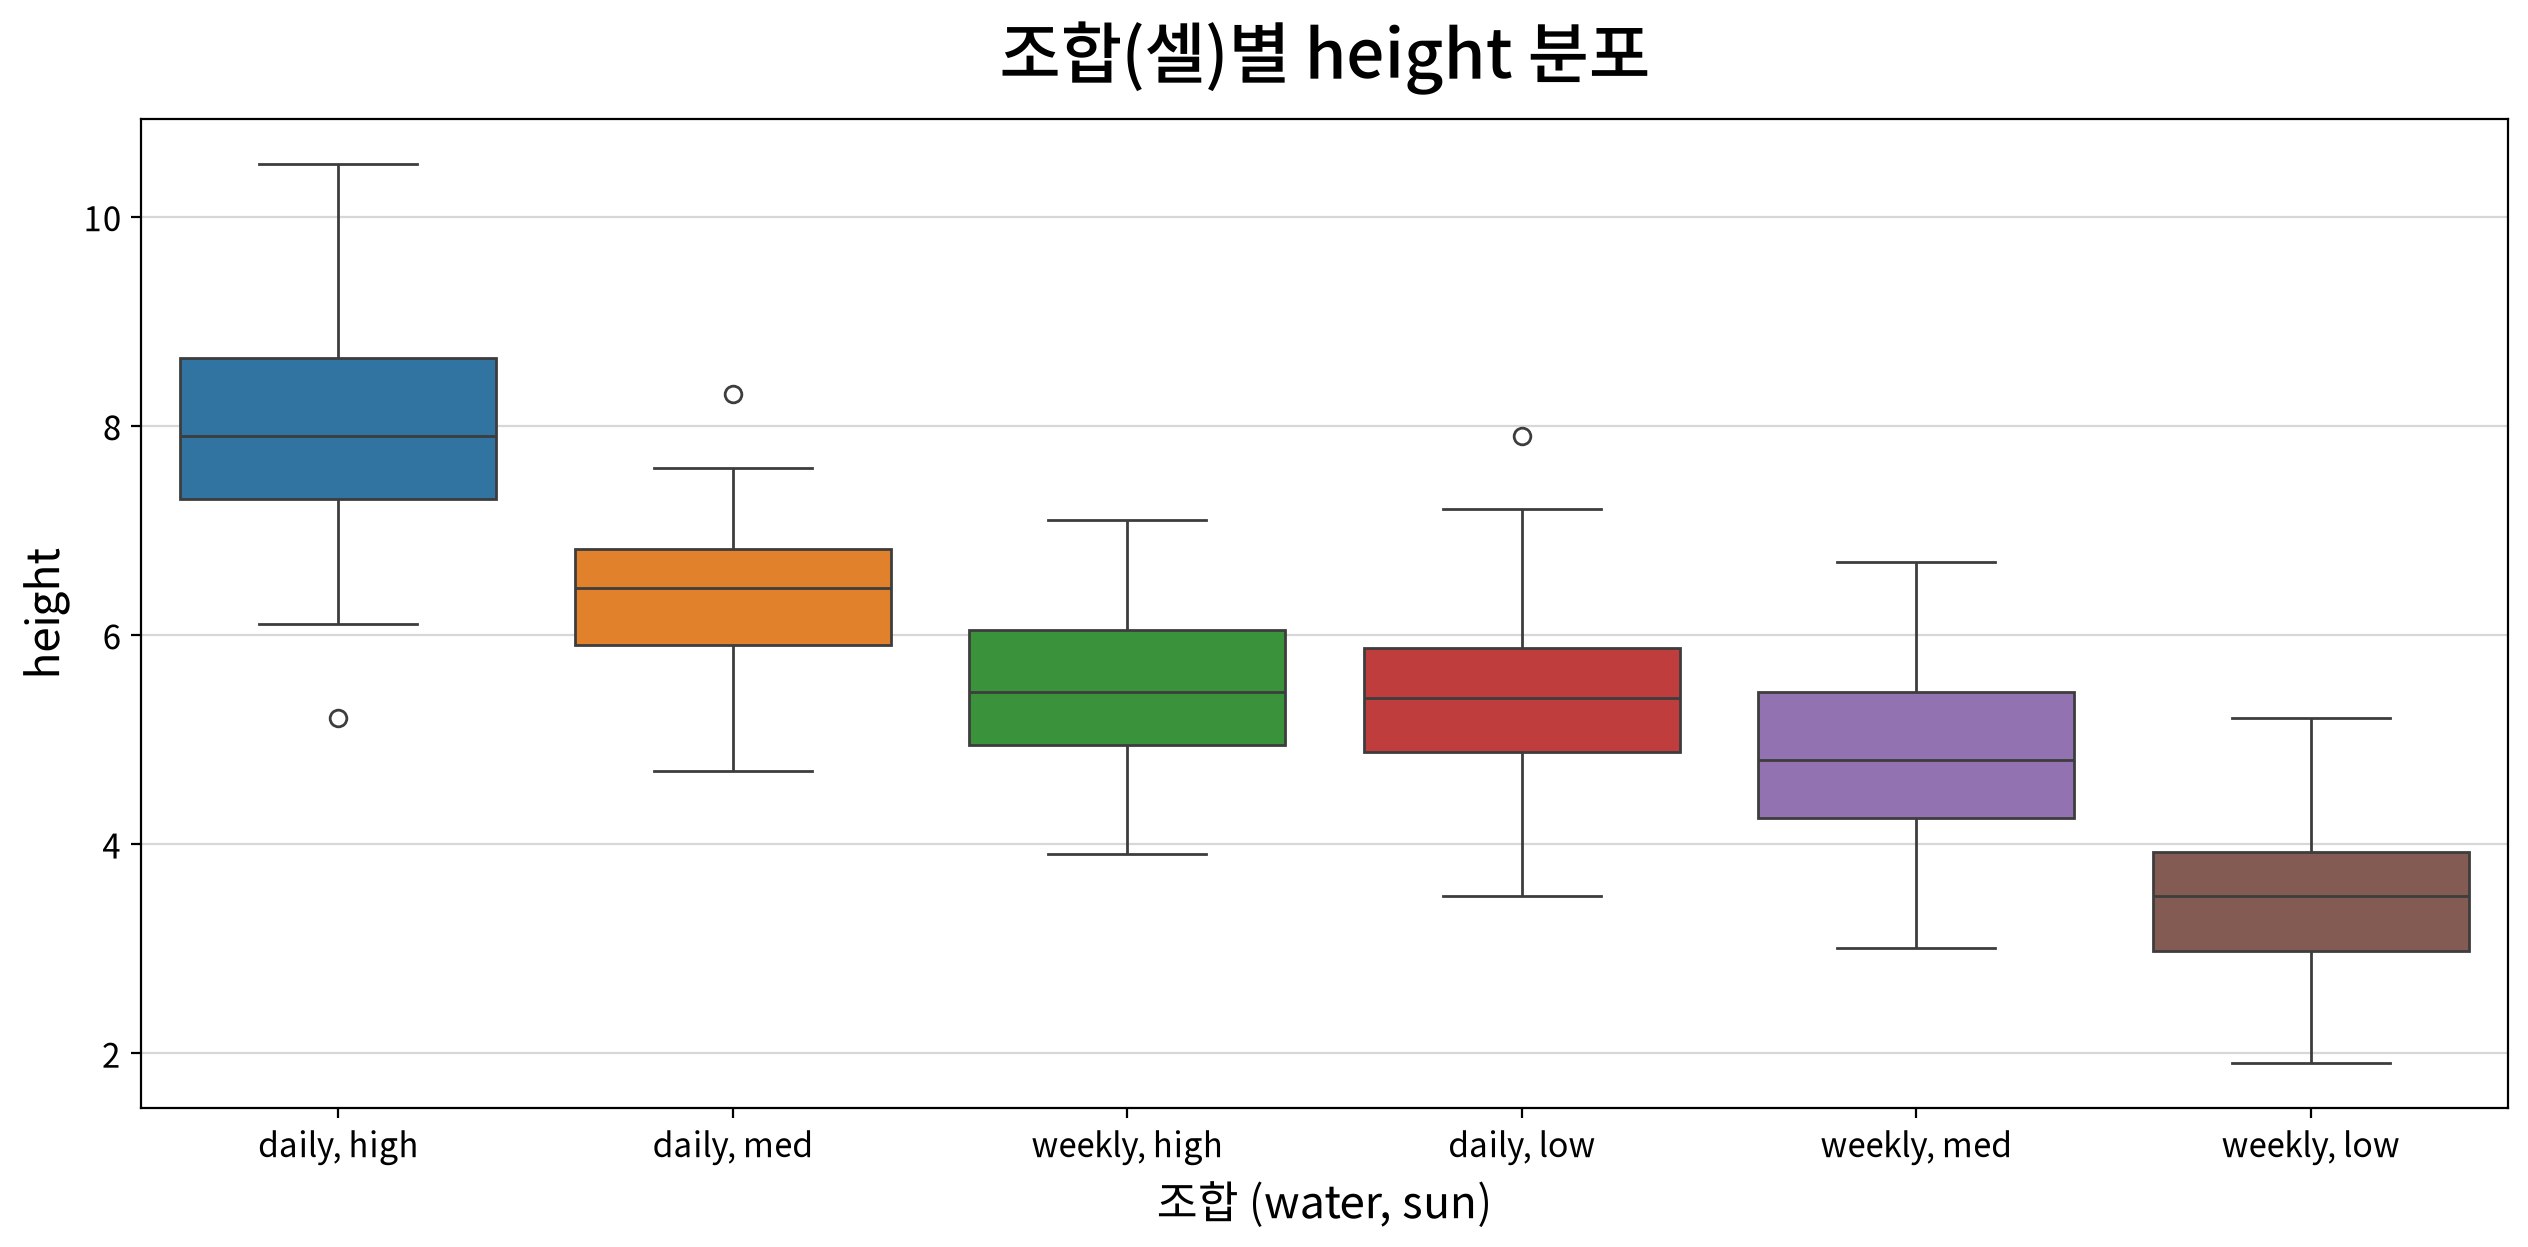

비교한 조합 쌍: 15개
유의한 쌍 : 12개
평균 차이가 가장 큰 쌍 :  (daily, high) vs (weekly, low)-> 차이 4.525, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (daily, low) vs (weekly, high)-> 차이 0.020, 효과크기 Negligible, p-value 1.000

[daily] 3쌍 중 유의한 쌍 : 3개
          A          B   diff  pval  significant
daily, high daily, low  2.515 0.000         True
daily, high daily, med  1.585 0.000         True
 daily, low daily, med -0.930 0.035         True

[weekly] 3쌍 중 유의한 쌍 : 2개
           A           B   diff  pval  significant
weekly, high weekly, low  2.030 0.000         True
 weekly, low weekly, med -1.375 0.000         True


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"daily, high","daily, low",7.980,5.465,2.515,0.307,8.199,0.000,2.165,True,Large
1,Tukey HSD,"daily, high","daily, med",7.980,6.395,1.585,0.307,5.167,0.000,1.488,True,Large
2,Tukey HSD,"daily, high","weekly, high",7.980,5.485,2.495,0.307,8.134,0.000,2.288,True,Large
3,Tukey HSD,"daily, high","weekly, low",7.980,3.455,4.525,0.307,14.752,0.000,4.216,True,Large
4,Tukey HSD,"daily, high","weekly, med",7.980,4.830,3.150,0.307,10.269,0.000,2.831,True,Large
5,Tukey HSD,"daily, low","daily, med",5.465,6.395,-0.930,0.307,-3.032,0.035,-0.969,True,Large
6,Tukey HSD,"daily, low","weekly, high",5.465,5.485,-0.020,0.307,-0.065,1.000,-0.020,False,Negligible
7,Tukey HSD,"daily, low","weekly, low",5.465,3.455,2.010,0.307,6.553,0.000,2.074,True,Large
8,Tukey HSD,"daily, low","weekly, med",5.465,4.830,0.635,0.307,2.070,0.310,0.627,False,Medium
9,Tukey HSD,"daily, med","weekly, high",6.395,5.485,0.910,0.307,2.967,0.042,1.043,True,Large


In [33]:
my_stats.posthoc_twoway(origin, y='height', 
                        between=['water', 'sun'], palette='tab10')

## #01. 연습문제 

In [ ]:
from jussam import load_data
from helpers import *
from pandas import melt

In [34]:
origin = load_data('edu')
origin.head()

📚 두 가지 교육방법을 비교하기 위하여 능력이 비슷한 고등학교 학생 22명을 추출하고, 11명씩 두 집단으로 나누어 한 학기 동안 각각의 교육방법으로 교육시킨 후 치른 학기말 시험 성적을 조사한 자료 (출처: 방송통신대학교 통계학 개론)


,교육방법,국어,영어
0,1,65,82
1,1,87,79
2,1,73,85
3,1,79,60
4,1,81,65


In [35]:
df = melt( origin, 
          id_vars='교육방법', 
          value_vars=['국어', '영어'], 
          var_name='과목',
          value_name='점수'
          )
df.head()

,교육방법,과목,점수
0,1,국어,65
1,1,국어,87
2,1,국어,73
3,1,국어,79
4,1,국어,81


In [ ]:
# 교육방법 2가지(1, 2) X 과목 2가지(국어, 영어)
# 2 X 2 = 4가지 

# 4개 조합에서 두 개를 고르는 조합의 수 
# (4 x 3)/2 = 6쌍 

C:\py_temp\15_LAB\helpers\my_plot.py:312: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data, x=x, y=y, hue=hue, orient=orient, order=order, palette=palette, ax=ax)


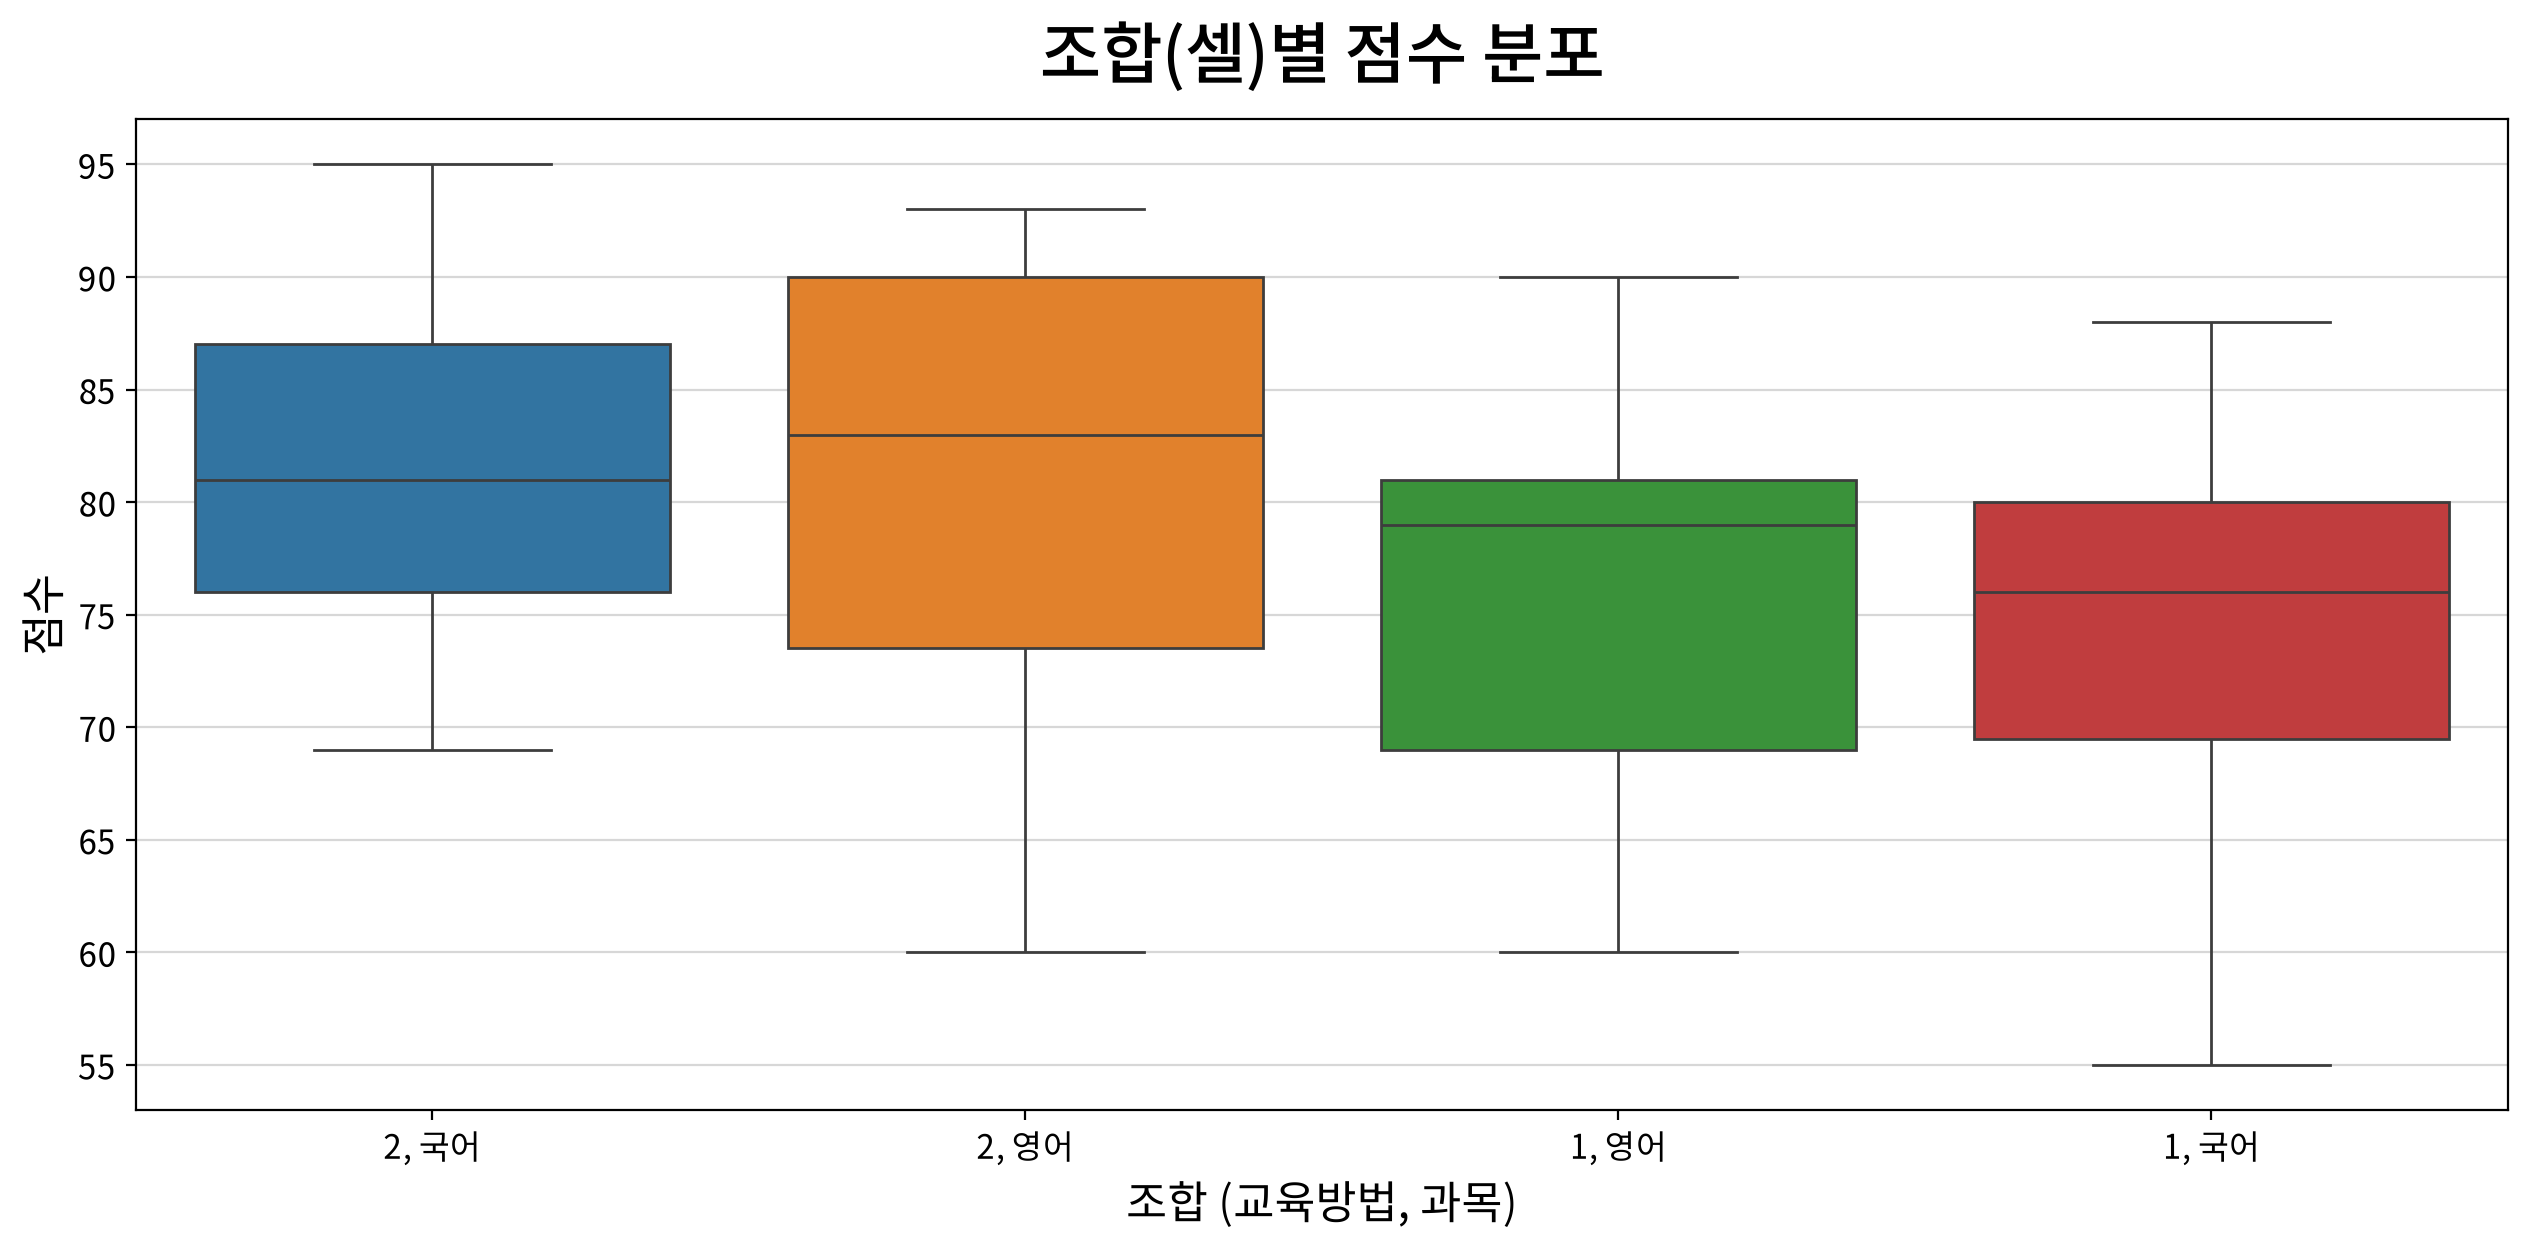

비교한 조합 쌍: 6개
유의한 쌍 : 0개
평균 차이가 가장 큰 쌍 :  (1, 국어) vs (2, 국어)-> 차이 6.818, 효과크기 Medium, p-value 0.356
평균 차이가 가장 작은 쌍: (2, 국어) vs (2, 영어)-> 차이 1.000, 효과크기 Negligible, p-value 0.995

[1] 1쌍 중 유의한 쌍 : 0개
(유의한 쌍 없음)

[2] 1쌍 중 유의한 쌍 : 0개
(유의한 쌍 없음)


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"1, 국어","1, 영어",74.545,75.818,-1.273,4.097,-0.311,0.989,-0.131,False,Negligible
1,Tukey HSD,"1, 국어","2, 국어",74.545,81.364,-6.818,4.097,-1.664,0.356,-0.740,False,Medium
2,Tukey HSD,"1, 국어","2, 영어",74.545,80.364,-5.818,4.097,-1.420,0.495,-0.530,False,Medium
3,Tukey HSD,"1, 영어","2, 국어",75.818,81.364,-5.545,4.097,-1.353,0.535,-0.624,False,Medium
4,Tukey HSD,"1, 영어","2, 영어",75.818,80.364,-4.545,4.097,-1.109,0.686,-0.425,False,Small
5,Tukey HSD,"2, 국어","2, 영어",81.364,80.364,1.000,4.097,0.244,0.995,0.098,False,Negligible


In [39]:
my_stats.posthoc_twoway(df, y='점수', 
                        between=['교육방법', '과목'], palette='tab10')

## #02. 연습문제 

In [54]:
origin = load_data("poisons")
origin.head()

📚 독극물 종류별로 동물의 생존시간을 기록한 실험 데이터 (출처: 방송통신대학교 통계학 개론)


,time,poison,treat
0,3.800,P1,T1
1,2.700,P1,T1
2,1.700,P1,T1
3,2.200,P1,T1
4,0.700,P1,T1


In [55]:
print(f"독극물 종류: {sorted(origin['poison'].unique())}")
print(f"해독제 종류: {sorted(origin['treat'].unique())}")
print(f"처리 조합(셀) 수: {origin.groupby(['poison', 'treat']).ngroups}")
print(f"조합당 개체 수: {origin.groupby(['poison', 'treat']).size().unique()}")

독극물 종류: ['P1', 'P2', 'P3']
해독제 종류: ['T1', 'T2', 'T3', 'T4']
처리 조합(셀) 수: 12
조합당 개체 수: [30]


In [ ]:
# 12개에서 두개를 고르는 조합의 수 
# (12 X 11) / 2 = 66 쌍 

C:\py_temp\15_LAB\helpers\my_plot.py:312: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=data, x=x, y=y, hue=hue, orient=orient, order=order, palette=palette, ax=ax)


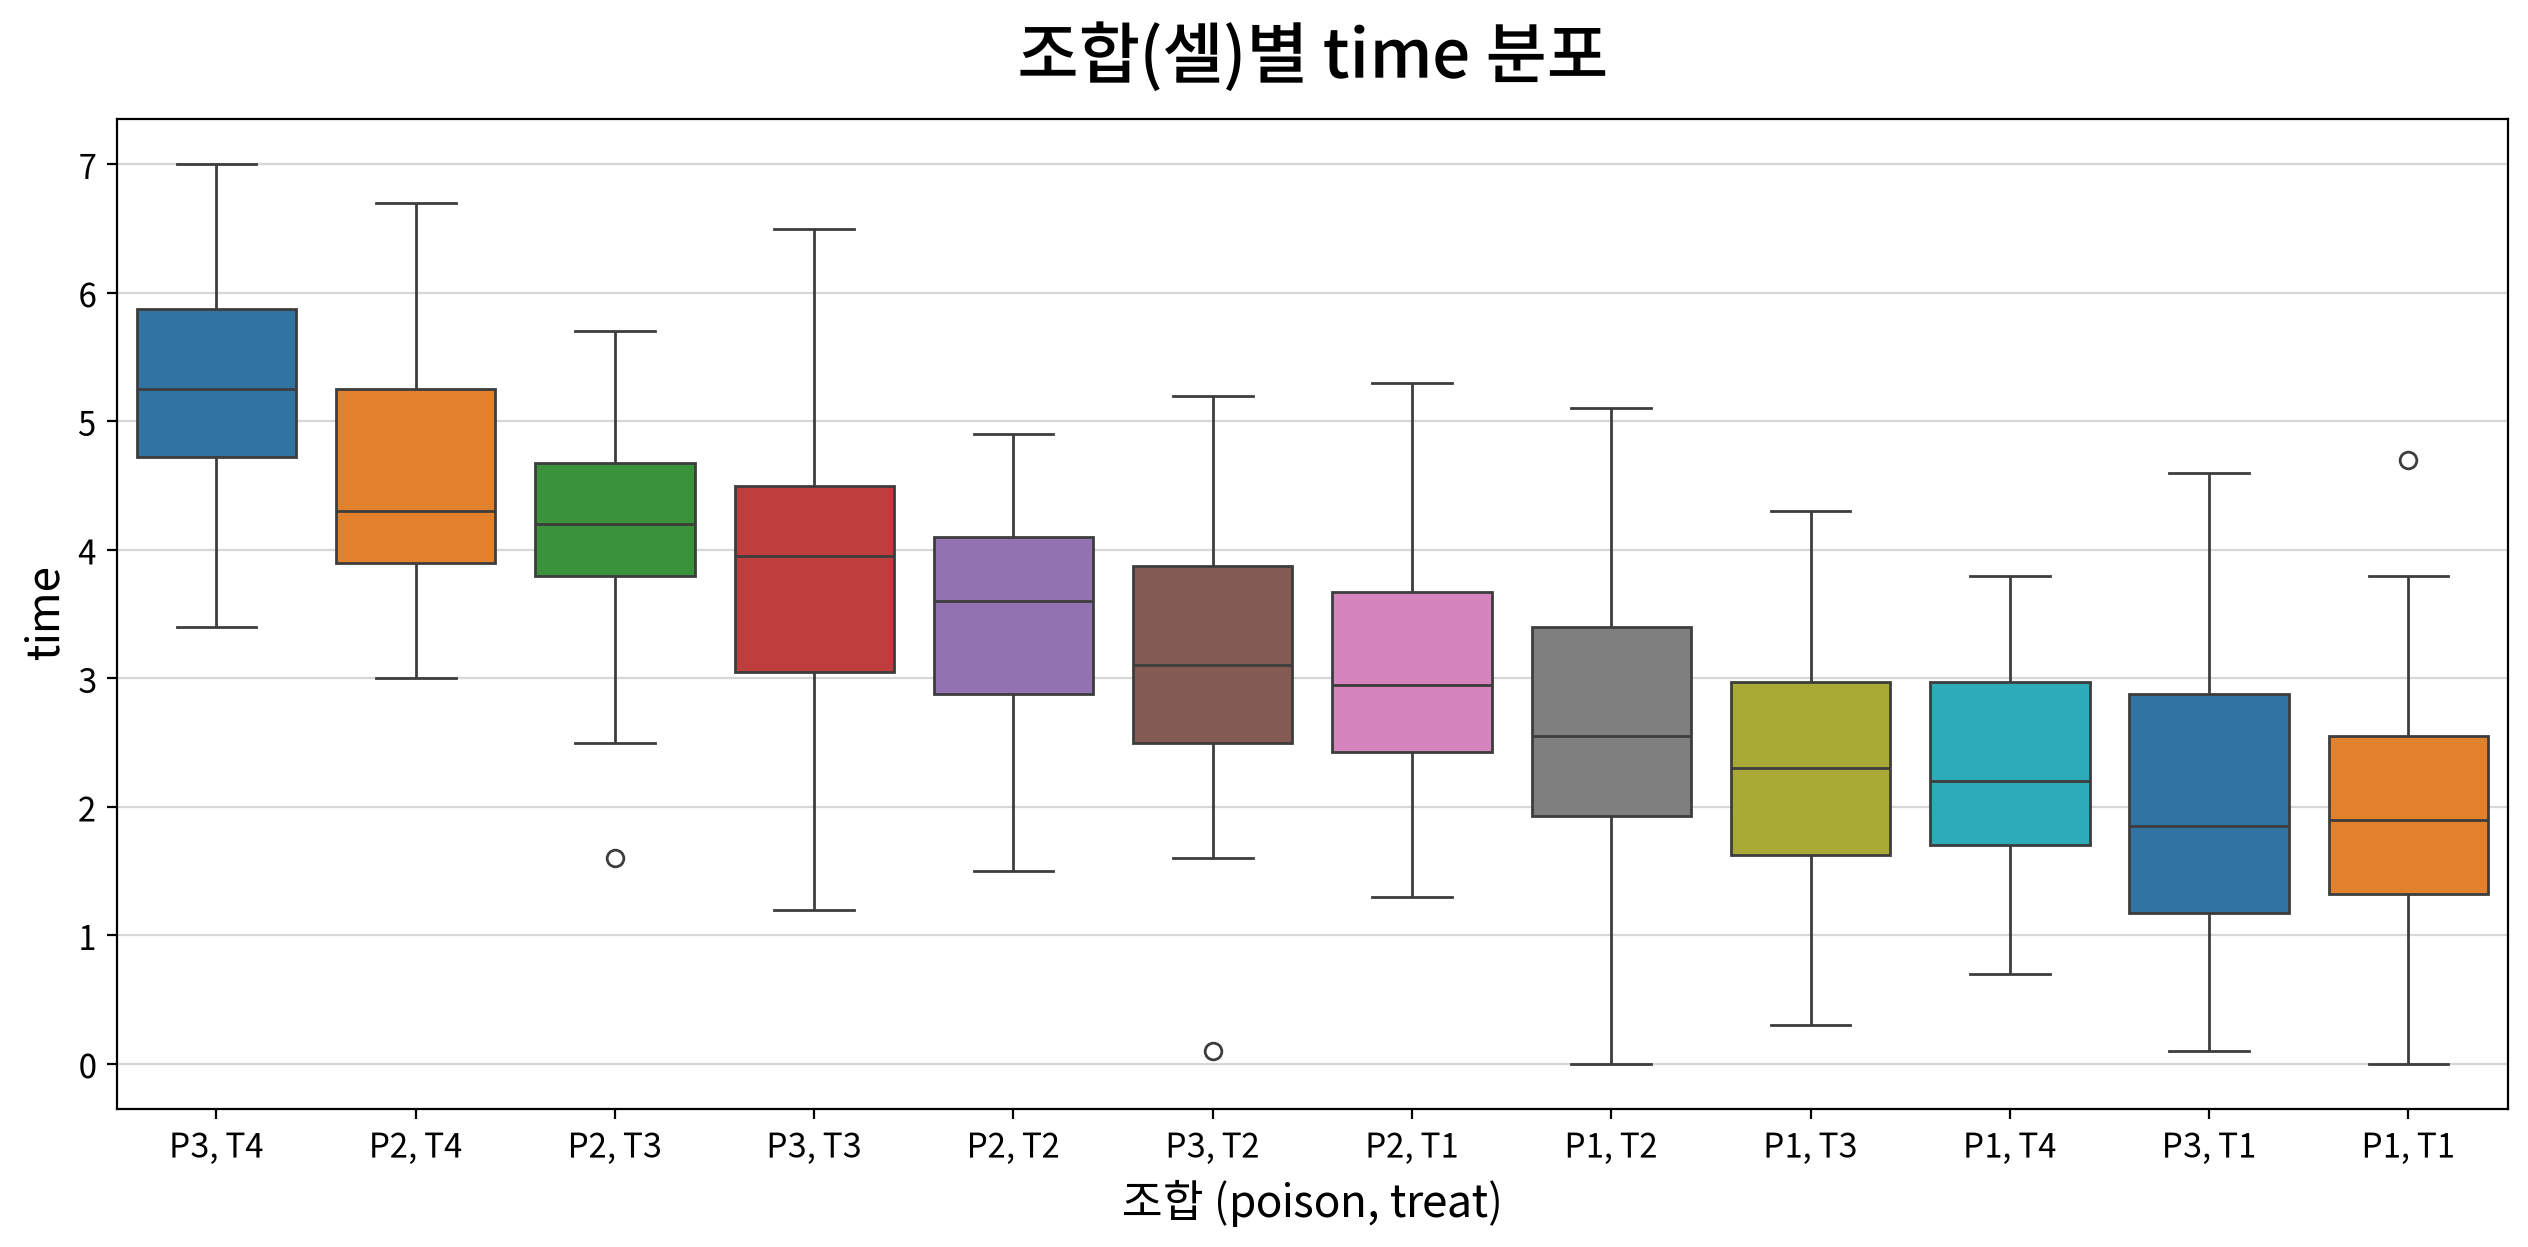

비교한 조합 쌍: 66개
유의한 쌍 : 38개
평균 차이가 가장 큰 쌍 :  (P1, T1) vs (P3, T4)-> 차이 3.307, 효과크기 Large, p-value 0.000
평균 차이가 가장 작은 쌍: (P2, T1) vs (P3, T2)-> 차이 0.053, 효과크기 Negligible, p-value 1.000

[P1] 6쌍 중 유의한 쌍 : 0개
(유의한 쌍 없음)

[P2] 6쌍 중 유의한 쌍 : 3개
     A      B   diff  pval  significant
P2, T1 P2, T3 -1.073 0.002         True
P2, T1 P2, T4 -1.467 0.000         True
P2, T2 P2, T4 -1.103 0.001         True

[P3] 6쌍 중 유의한 쌍 : 5개
     A      B   diff  pval  significant
P3, T1 P3, T2 -1.083 0.002         True
P3, T1 P3, T3 -1.710 0.000         True
P3, T1 P3, T4 -3.247 0.000         True
P3, T2 P3, T4 -2.163 0.000         True
P3, T3 P3, T4 -1.537 0.000         True


,test,A,B,mean_A,mean_B,diff,se,T,pval,hedges,significant,effect_size
0,Tukey HSD,"P1, T1","P1, T2",1.980,2.670,-0.690,0.258,-2.677,0.243,-0.649,False,Medium
1,Tukey HSD,"P1, T1","P1, T3",1.980,2.370,-0.390,0.258,-1.513,0.936,-0.402,False,Small
2,Tukey HSD,"P1, T1","P1, T4",1.980,2.280,-0.300,0.258,-1.164,0.991,-0.328,False,Small
3,Tukey HSD,"P1, T1","P2, T1",1.980,3.070,-1.090,0.258,-4.228,0.002,-1.056,True,Large
4,Tukey HSD,"P1, T1","P2, T2",1.980,3.433,-1.453,0.258,-5.638,0.000,-1.480,True,Large
5,Tukey HSD,"P1, T1","P2, T3",1.980,4.143,-2.163,0.258,-8.392,0.000,-2.203,True,Large
6,Tukey HSD,"P1, T1","P2, T4",1.980,4.537,-2.557,0.258,-9.917,0.000,-2.569,True,Large
7,Tukey HSD,"P1, T1","P3, T1",1.980,2.040,-0.060,0.258,-0.233,1.000,-0.057,False,Negligible
8,Tukey HSD,"P1, T1","P3, T2",1.980,3.123,-1.143,0.258,-4.435,0.001,-1.110,True,Large
9,Tukey HSD,"P1, T1","P3, T3",1.980,3.750,-1.770,0.258,-6.866,0.000,-1.583,True,Large


In [57]:
my_stats.posthoc_twoway(origin, y='time', 
                        between=['poison', 'treat'], palette='tab10')